# mSWE-GNN: paper walkthrough + pretrained-model reproduction — FAST VARIANT (Multi-scale hydraulic graph neural networks for flood modelling)

**Paper**: Bentivoglio, Isufi, Jonkman & Taormina, *Multi-scale hydraulic graph neural networks for flood modelling*, Nat. Hazards Earth Syst. Sci. 25, 335–351, 2025, [doi:10.5194/nhess-25-335-2025](https://doi.org/10.5194/nhess-25-335-2025) (open access, CC BY 4.0).
**Code**: `mSWE-GNN-main/` (upstream repo v1.1, Nov 2024, git 529bb92). This notebook lives in the repo root and imports the authors' own `utils/`, `models/` and `training/` modules.
**Data**: Zenodo [10.5281/zenodo.13326595](https://doi.org/10.5281/zenodo.13326595), unpacked into `database/raw_datasets_mesh/` (100 D-HYDRO simulations) and `database/raw_datasets_dk15/` (11 dike-ring-15 simulations), then converted into `database/datasets/{train,test}/*.pkl`.

## What this notebook does
Two layers of content, interleaved and ordered **the way the paper is written**:
1. **Paper walkthrough** (markdown + the paper's own figures, taken from the open-access article page and stored in `paper_figures/`): the research problem and the gap, the method (multi-scale mesh, architecture, boundary conditions, loss), the experimental setup, the results, the discussion.
2. **Reproduction** (code cells, already executed on 1×H100 with outputs saved): training is **completely frozen**. We only load the 17 checkpoints shipped with the repo (`results/Pareto_front/models/K{2..5}_F{16,32,50,64}.h5`, `results/finetuned_dk15.h5`), roll them out on the real test sets and visualise the result. Subsections titled "**In the code / data**" are the reproduction; everything else is the paper.

| Notebook section | Paper | Content |
|---|---|---|
| 0 | — | Reproduction setup: environment, data, checkpoints |
| 1 | §1 Introduction | The problem, the four limitations of SWE-GNN, the contribution |
| 2 | §2 Methodology | Overall framework (Fig 1), multi-scale mesh and graph (Fig 2), encoder/processor/decoder, boundary conditions (Fig 3), rotation-invariant inputs, loss (Fig 13) |
| 3 | §3 Experimental setup | Synthetic dataset (Fig 4, Fig 6, Table 1), dike ring 15 (Fig 5), normalisation, training setup (Table D1), metric definitions |
| 4 | §4 Results | Comparison with SWE-GNN (Fig 8, Fig 7, Fig 12, Table A1) + reproduction; transfer to dike ring 15 (Fig 9–11, Table 2) + reproduction; ablation (Table 3) |
| 5 | §5–6 + Appendix C | Strengths, limitations, future work; speed-up from parallel inference (Fig 14) |
| 6 | — | Reproduction findings and cluster-specific pitfalls |

**Environment**: conda env `mswegnn` (torch 2.1.0, torch_geometric 2.4.0, lightning 2.0.9.post0). The whole notebook takes about 20–25 min on 1×H100; section 4.1.5 is slow on CPU, set `RUN_ALL_CHECKPOINTS=False` to skip it.


> ## Fast variant — read this first
>
> This is the **executable** version of the walkthrough, trimmed so it finishes in roughly
> **8 minutes on a CPU-only JupyterHub container** instead of about 4 hours. Three changes,
> each marked `FAST VARIANT` in the code with the original line left commented above it:
>
> | Change | Full notebook | Here | Saves |
> |---|---|---|---|
> | Synthetic test simulations | 20 | **3** | ~11 min |
> | 16-checkpoint Pareto sweep | run | **skipped**, plotted from the authors' csv | ~3.5 h |
> | Dike-ring-15 test simulations | 10 | **2** | ~11 min |
>
> **The metrics printed here are computed over 3 simulations, not 20, so they will not
> match the paper or the full notebook.** They are for checking that the workflow runs, not
> for quoting. For the reproduction numbers — CSI₀.₀₅ 0.803 against the authors' recorded
> 0.830, and the depth RMSE that does not reproduce — see `test_pretrained_EN.ipynb`, which
> carries the saved outputs of a full 20-simulation run on an H100 and needs no execution to
> read.
>
> Nothing else differs: the same checkpoints, the same data pipeline, the same autoregressive
> rollout, the same metric definitions and the same figures.


## 0. Reproduction setup: environment, data and checkpoints

In [ ]:
%matplotlib inline
import os, sys, time, glob, json, platform
import numpy as np, pandas as pd, torch, matplotlib as mpl, matplotlib.pyplot as plt
import lightning as L, wandb
from copy import copy
sys.path.insert(0, os.getcwd())

from utils.visualization import *
from utils.dataset import *
from utils.miscellaneous import *
from utils.load import *
from utils.scaling import *
from models.gnn import *
from training.train import *
from database.graph_creation import *
from torch_geometric.loader import DataLoader

import importlib.metadata as md_
print("python", platform.python_version(), "| torch", torch.__version__, "| torch_geometric", md_.version("torch_geometric"),
      "| lightning", md_.version("lightning"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")
torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision("high")

mpl.rcParams.update({"grid.color": "k", "grid.linestyle": ":", "grid.linewidth": 0.5,
                     "figure.figsize": [7, 5], "figure.dpi": 100, "font.size": 12,
                     "legend.fontsize": "small", "font.family": "serif"})

### 0.1 Data and checkpoint check
`config.yaml` is the authors' reference configuration; its `saved_model` field points at the checkpoint to be tested.
`create_model_dataset` loads both the train and the test pickle (the training split is used **only** to fit the feature-normalisation scalers — no training happens here).

In [ ]:
CFG_FILE = "config.yaml"
cfg = read_config(CFG_FILE)
print(json.dumps({k: cfg[k] for k in ["dataset_parameters", "temporal_dataset_parameters", "models"]}, indent=1))
print("saved_model:", cfg["saved_model"])

ckpts = sorted(glob.glob("results/Pareto_front/models/*.h5")) + ["results/finetuned_dk15.h5"]
print(f"\n{len(ckpts)} checkpoints shipped with the repo:")
for c in ckpts: print(f"  {c:48s} {os.path.getsize(c)/1e6:6.1f} MB")
for split in ["train", "test"]:
    for f in sorted(glob.glob(f"database/datasets/{split}/*.pkl")):
        print(f"  {f:60s} {os.path.getsize(f)/1e6:8.1f} MB")

### 0.2 Load the test dataset (20 synthetic simulations)
Each sample is a PyG `Data` object: `WD`/`VX`/`VY` have shape `[num_nodes, 97]` (96 h, one frame per hour; the config's `temporal_res=120 min` subsamples every other frame into 49 steps); `node_ptr` delimits the node ranges of the 4 scales; `BC` is the inflow hydrograph.

In [ ]:
wandb.finish()
wandb.init(mode="disabled", config=cfg)
fix_dict_in_config(wandb)
config = wandb.config
L.seed_everything(config.models["seed"])

dataset_parameters = config.dataset_parameters
scalers = config.scalers
selected_node_features = config.selected_node_features
selected_edge_features = config.selected_edge_features

t0 = time.time()
train_dataset, val_dataset, test_dataset, scalers = create_model_dataset(
    scalers=scalers, device=device, **dataset_parameters, **selected_node_features, **selected_edge_features)
print(f"loaded in {time.time()-t0:.0f}s: train {len(train_dataset)} / val {len(val_dataset)} / test {len(test_dataset)} simulations")
del train_dataset, val_dataset   # not needed: no training in this notebook

# ---------------- FAST VARIANT ----------------------------------------------------
# The full notebook evaluates all 20 test simulations, which takes ~13 min on a CPU-only
# container. Keeping the first 3 cuts every rollout below proportionally.
# load_dataset(seed=0) does not shuffle, so these are seeds 81..83, and
# get_numerical_times(..., len(test_dataset)) slices the matching rows of overview.csv,
# so the speed-up figures stay correctly paired.
N_TEST = 3
test_dataset = test_dataset[:N_TEST]
print(f"FAST VARIANT: keeping {len(test_dataset)} of 20 test simulations")
# ----------------------------------------------------------------------------------

temporal_dataset_parameters = config.temporal_dataset_parameters
temporal_test_dataset_parameters = get_temporal_test_dataset_parameters(config, temporal_dataset_parameters)
temporal_res = dataset_parameters["temporal_res"]
previous_t = temporal_dataset_parameters["previous_t"]
test_dataset_name = dataset_parameters["test_dataset_name"]

rows = []
for i, d in enumerate(test_dataset):
    ptr = d.node_ptr.tolist()
    rows.append({"sim": i, "nodes(all scales)": d.num_nodes, "fine": ptr[1]-ptr[0], "s1": ptr[2]-ptr[1], "s2": ptr[3]-ptr[2], "coarse": ptr[4]-ptr[3],
                 "edges": d.edge_index.shape[1], "time steps": d.WD.shape[1], "max WD [m]": float(d.WD.max()), "max q": float(d.V.max()),
                 "peak inflow [m2/s]": float(d.BC.max())})
df_sims = pd.DataFrame(rows).set_index("sim")
df_sims.round(3)

## 1. Introduction: the problem and the gap

**The problem.** Dike- and dam-breach flood mapping relies on numerical models that solve the 2-D shallow water equations (SWE), such as D-HYDRO / Delft3D FM. They are accurate, but one 96-hour simulation takes hours (12 h 20 min for the 20 synthetic cases and 47 h 15 min for the 10 dike-ring-15 cases, see Table A1), which rules out probabilistic, many-scenario assessment. Deep-learning surrogates can be orders of magnitude faster, but most of them have to be retrained for every new area.

**The starting point.** The authors' earlier **SWE-GNN** (a hydraulic-based graph neural network) treats the finite-volume mesh as a graph and lets a GNN propagate water between neighbouring cells. It transfers to unseen domains and can embed physical constraints.

**The gap (the four limitations listed in the abstract):**
1. **It cannot represent large differences in propagation speed** — information travels one hop per layer, so a fast flood wave needs many layers.
2. **Training becomes unstable with many layers** — SWE-GNN needs 10–18 of them (Table D1); deep message passing is hard to train and slow at inference.
3. **It cannot take time-varying boundary conditions**, such as a breach discharge hydrograph.
4. **It needs initial conditions from a numerical solver.**

**The proposal: mSWE-GNN** (multi-scale SWE-GNN)
- Build **several mesh resolutions** over the same domain (4 scales) and arrange them into a **U-shaped** multi-scale GNN: fine → coarse → fine. One hop on a coarse scale covers a long physical distance, so a few layers per scale (2–5) let information cross the domain, while the finest scale (which holds most of the nodes) does *less* work than before.
- Inject the time-varying discharge hydrograph through a **ghost cell** as a directed edge, and roll out autoregressively from a dry bed ($t=0$, no water), with no dependence on a numerical solver.
- Use only **rotation-invariant** inputs (area, elevation, roughness, water depth, **magnitude** of unit discharge, dual edge length).
- The decoder is a 1-D convolution along the time axis plus an MLP that outputs the next $h$ and $|q|$ directly, with a ReLU enforcing non-negativity.

**Headline results** (from the abstract): MAE ≈ 0.05 m for water depth and ≈ 0.003 m² s⁻¹ for unit discharge on the synthetic test set; speed-up > 700× on the real case study (dike ring 15 in the Netherlands), reaching CSI$_{0.05\,\mathrm{m}}$ = 87.68 % after fine-tuning on a **single** simulation.

## 2. Methodology

### 2.0 Overall framework (paper Fig. 1)

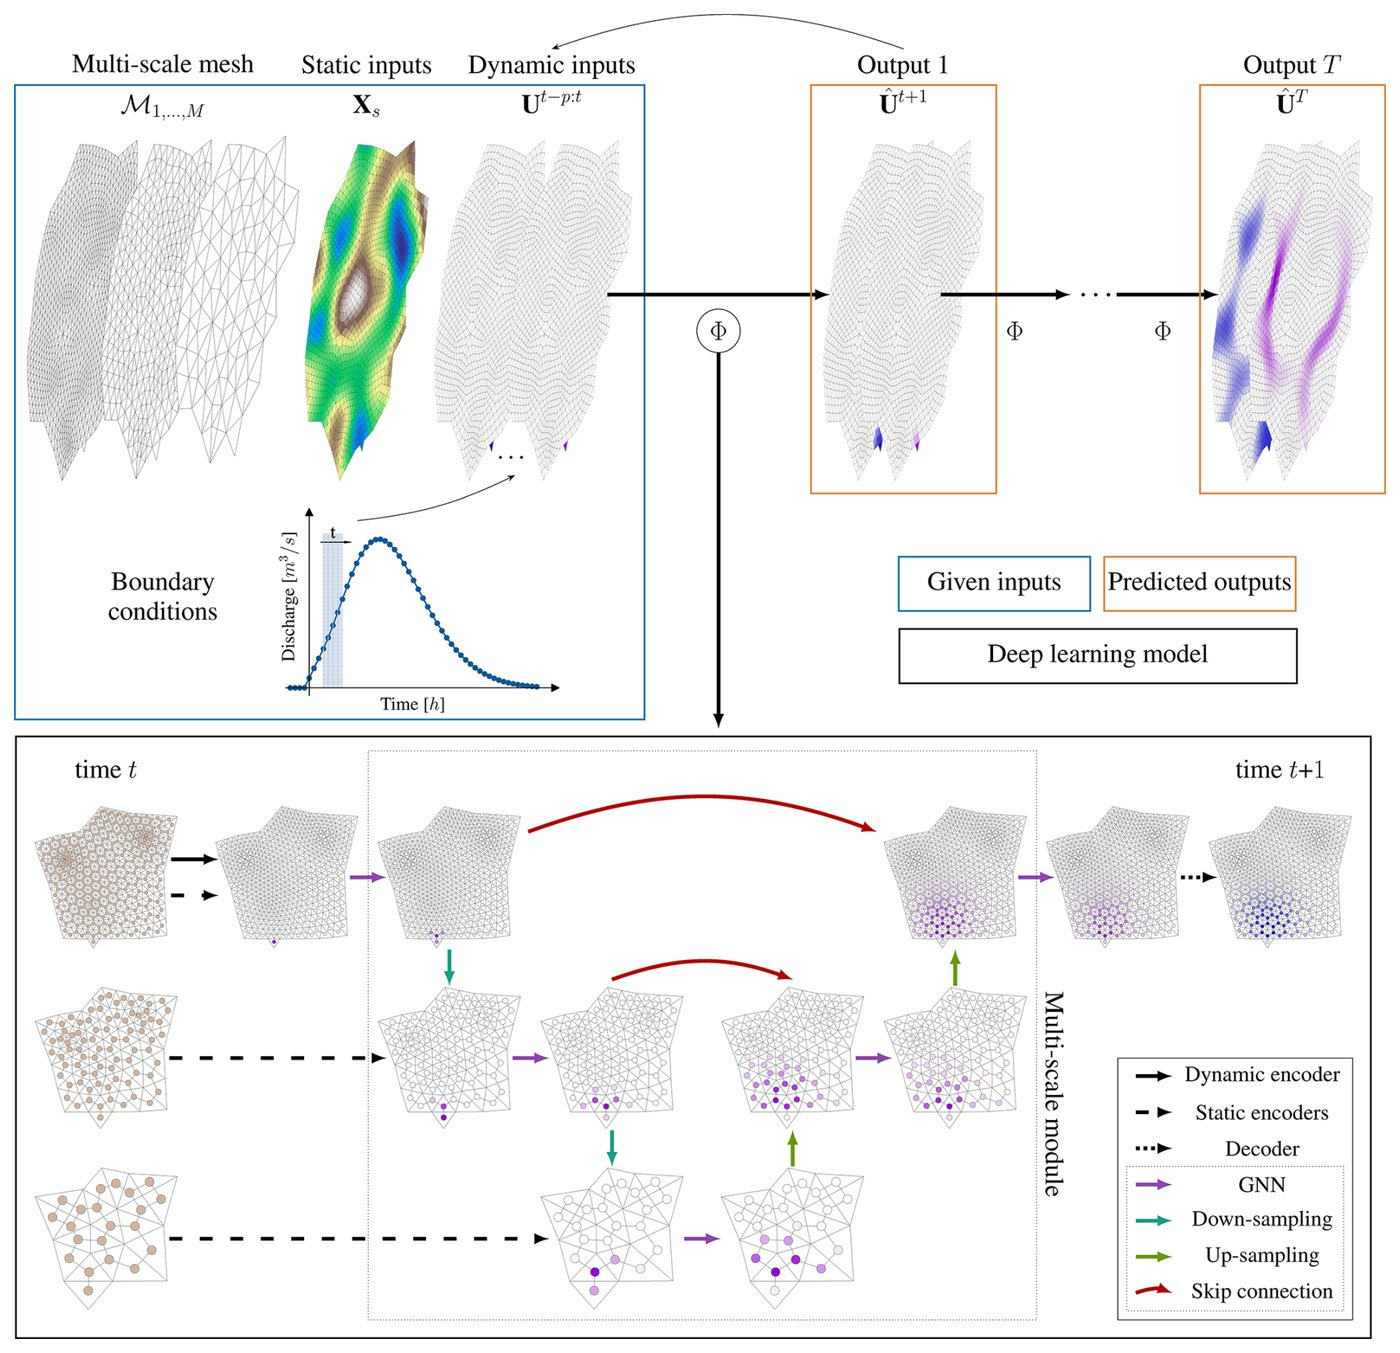

*Fig. 1 —* The model $\Phi(\cdot)$ takes (blue box) a fine mesh and its progressively coarsened versions $\mathcal{M}_{1..M}$, the **static inputs** $\mathbf{X}_s$ defined on them (DEM and so on), the **dynamic inputs** $\mathbf{U}^{t-p:t}$ (water depth and discharge at the previous $p+1$ times) and the **boundary condition** (the current slice of the breach hydrograph); it outputs (orange box) the hydraulic variables at the next time, $\hat{\mathbf{U}}^{t+1}$. Feeding the output back in as the next input rolls the prediction forward to $T$. The lower half is the **multi-scale module**: a GNN runs on the fine scale (purple arrows), the state is downsampled (green) to the coarser scale for another GNN, and after the coarsest scale it is upsampled step by step (yellow-green) and added to the matching downward features (red skip connections), before the decoder produces the output.

*Figure source: Bentivoglio et al., NHESS 25, 335–351, 2025, [doi:10.5194/nhess-25-335-2025](https://doi.org/10.5194/nhess-25-335-2025), CC BY 4.0.*

### 2.1 Multi-scale mesh and multi-scale graph (§2.1, paper Fig. 2)

**Mesh generation** (only the boundary polygon of the area is needed): MeshKernel first produces a coarse mesh; splitting every edge in two and connecting the new points gives the next finer level; the result is then orthogonalised (required by Delft3D's staggered grid) and over-elongated cells are removed, leaving a mixture of triangles and quadrilaterals. Repeating this yields $M$ scales (4 in this paper).

**Graph definition**: nodes are cell barycentres, edges connect cells that share a face (the dual graph). The rule for connecting scales is simple: **if a fine cell's centre falls inside a coarse cell, a directed inter-scale edge is added between the two**.

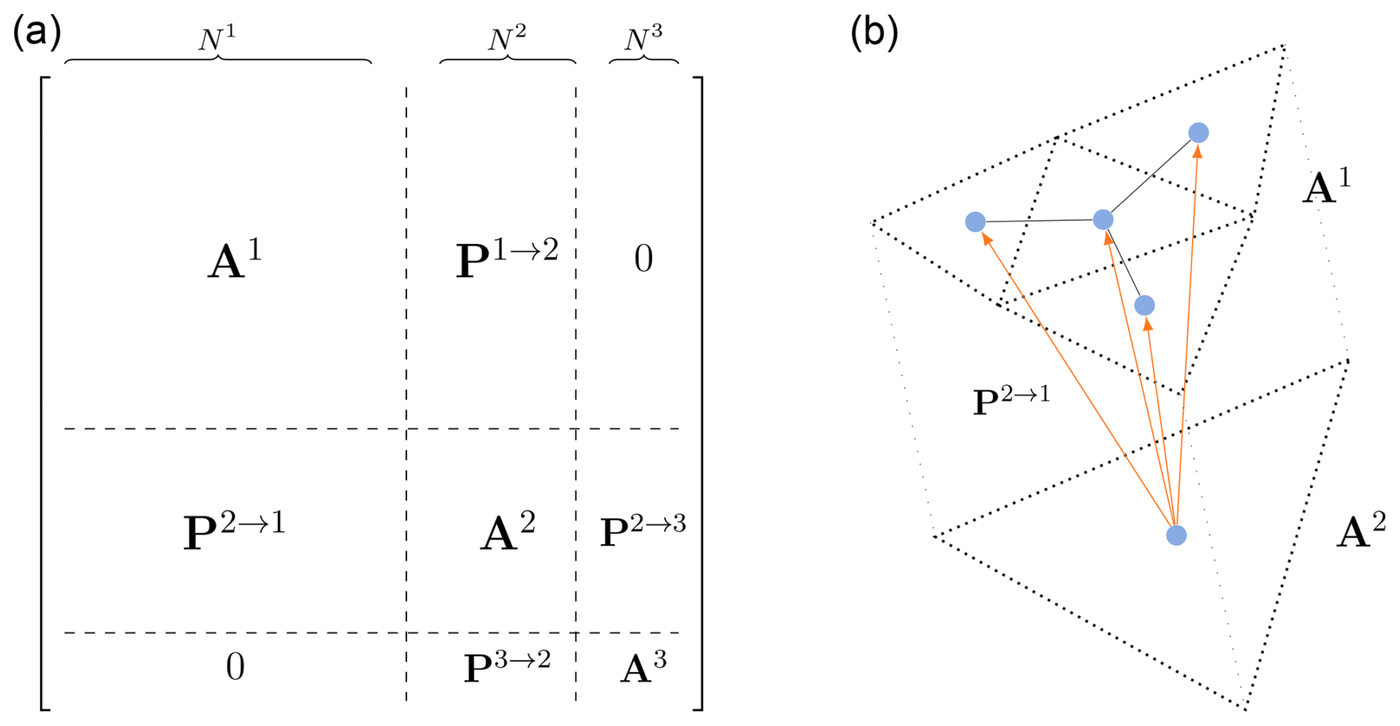

*Fig. 2 —* (a) A three-scale multi-scale graph can be written as one block adjacency matrix: the diagonal blocks $\mathbf{A}^m \in \mathbb{R}^{N^m\times N^m}$ are each scale's own adjacency matrix, and the off-diagonal blocks $\mathbf{P}^{m\to n} \in \mathbb{R}^{N^m\times N^n}$ ($n = m\pm1$) are the **prolongation matrices** between neighbouring scales; non-adjacent scales are zero. (b) Example connection between a fine mesh $\mathbf{A}^1$ and a coarse mesh $\mathbf{A}^2$: $\mathbf{P}^{2\to1}$ links one coarse cell to all the fine cells it covers.

**Downsampling / upsampling** (Eq. 5–6):
- fine → coarse: **mean pooling**, a coarse node's features are the average of the fine nodes attached to it (no parameters);
- coarse → fine: a **learnable** operator, $\mathbf{h}^{m}_{d,i} \leftarrow \psi_{m+1\to m}(\cdot)\cdot \mathbf{h}^{m+1}_{d}$, where multiplying by the coarse node's dynamic features guarantees that **water only propagates down to the fine cells if the coarse cell holds water**.

*Figure source: Bentivoglio et al., NHESS 25, 335–351, 2025, [doi:10.5194/nhess-25-335-2025](https://doi.org/10.5194/nhess-25-335-2025), CC BY 4.0.*

#### In the code / data: the four mesh scales of test sim 0
Each simulation's domain is a random polygon; meshkernel builds a triangular mesh and refines it three times. The four scales hold roughly 10 000 / 2 500 / 600 / 150 cells. The coarse scales are what let information cross the domain within a few GNN layers (the long-range action of shallow-water waves).

In [ ]:
sample = test_dataset[0]
mesh = sample.mesh
print(mesh)
for k, m in enumerate(mesh.meshes):
    print(f"  scale {k}: {m.num_faces} faces, {m.num_edges} edges, median face area {np.median(m.face_area):.0f} m2")
plot_multiscale_mesh_properties(mesh.meshes, with_area=True, width=0.3)

### 2.2 Architecture: encoder → processor (U-shaped multi-scale GNN) → decoder (§2.2)

**Encoder (Eq. 2)** — three shared three-layer MLPs map the inputs into a latent space of dimension $G$:
- static node features $\mathbf{x}_{s,i} = (a_i, e_i, m_i, w_i)$: cell area, elevation, Manning roughness, (boundary) water level → $\phi_s$;
- dynamic node features $\mathbf{x}^t_{d,i} = (h^{t-p:t}_i, |q|^{t-p:t}_i)$: water depth and unit-discharge magnitude over the previous $p+1$ times ($p=2$; the code's `previous_t=3` is the same 3 frames) → $\phi_d$;
- edge features $\boldsymbol{\varepsilon}_{ij} = (l_{ij})$: dual edge length → $\phi_\varepsilon$.
Static and dynamic features on the coarse scales come from mean pooling the finest scale.

**Processor: the GNN layer (Eq. 3–4)**

$$\mathbf{s}^{(\ell+1)}_{ij} = \psi\big(\mathbf{h}_{s,i},\ \mathbf{h}_{s,j},\ \mathbf{h}^{(\ell)}_{d,i},\ \mathbf{h}^{(\ell)}_{d,j},\ \boldsymbol{\varepsilon}'_{ij}\odot(\mathbf{h}^{(\ell)}_{d,j}-\mathbf{h}^{(\ell)}_{d,i})\big),\qquad
\mathbf{h}^{(\ell+1)}_{d,i} = \mathbf{h}^{(\ell)}_{d,i} + \sum_{j\in\mathcal{N}_i}\mathbf{s}^{(\ell+1)}_{ij}\mathbf{W}^{(\ell+1)}$$

$\psi:\mathbb{R}^{5G}\to\mathbb{R}^{G}$ is an MLP and $\mathbf{W}\in\mathbb{R}^{G\times G}$ is learnable. The difference term $\mathbf{h}_{d,j}-\mathbf{h}_{d,i}$ models the **hydraulic gradient**: only a node that already holds water can push water to its neighbours. That is the physical constraint built into the model, and the reason it is called "hydraulic-based".

**U-shaped ordering**: $L$ GNN layers per scale (`K` in the code), downsampling fine → coarse and upsampling coarse → fine; after upsampling, the features are added to the downward branch at the same scale (**skip connection**, Eq. 7: $\mathbf{h}^m_d \leftarrow \mathbf{h}^{m\downarrow}_d + \mathbf{h}^{m\uparrow}_d$) before the next group of GNN layers.

**Decoder (Eq. 8)**

$$\hat{u}^{t+1}_i = \mathrm{ReLU}\big(\mathbf{U}^{t-p:t}_i\,\mathbf{w}_p + \varphi(\mathbf{h}_{d,i})\big)$$

The first term is a **1-D convolution** along the time axis ($\mathbf{w}_p\in\mathbb{R}^{p+1}$ learnable, effectively a linear extrapolation of the last few frames); the second is a three-layer MLP decoding the latent features. The ReLU keeps depths and discharges non-negative. Note that this predicts the **absolute value at the next step**, not an increment as SWE-GNN does (Table 3 ablates a residual decoder).

**The configuration selected in the paper**: $L=4$ layers per scale, $G=64$, 4 scales, about **811 000** parameters — that is `K4_F64.h5` in the repo, loaded in section 3.4 below. `Architecture.png` in the repo root is a high-resolution diagram of the same architecture.

### 2.2.1 Receptive field and compute cost: why "4 layers per scale" is enough

The sentence above — "the coarse scales let information cross the domain within a few GNN layers" — needs to be made quantitative, because it is only half right.

**Premise: the refinement rule fixes the ratios between scales.** Refinement splits every edge in two, so neighbouring scales differ by **a factor 2 in length and a factor 4 in cell count**. Measured on test sim 0 (printed by the cell above) and on dike ring 15 (§4.2); the hop distance is the median distance between neighbouring cell barycentres, `face_distance`, read from the un-normalised pickles:

| Scale | Cells, synthetic test sim 0 | Hop | Cells, dike ring 15 | Hop |
|---|---|---|---|---|
| $\mathcal{M}_1$ finest | 11 837 | 91 m | 22 881 | 98 m |
| $\mathcal{M}_2$ | 2 961 (÷4.00) | 185 m (×2.02) | 5 724 (÷4.00) | 198 m (×2.02) |
| $\mathcal{M}_3$ | 741 (÷4.00) | 371 m (×2.00) | 1 433 (÷3.99) | 396 m (×2.00) |
| $\mathcal{M}_4$ bottleneck | 186 (÷3.98) | 739 m (×1.99) | 359 (÷3.99) | 785 m (×1.98) |

The ratios are exactly 4 and 2. The `node_ptr [0, 22881, 28605, 30038, 30397]` printed in §4.2 says the same thing: $22\,881\times(1+\tfrac14+\tfrac1{16}+\tfrac1{64}) \approx 30\,400$, i.e. the "30 397 nodes" are the sum over the four scales, and the finest scale alone holds 22 881.

**The receptive field accumulates along the U path.** Each scale's GNN module performs $K=4$ hops (`models.K` in `config.yaml`; the code builds `self.K = [K]*4 + [K]*3`, i.e. 7 modules), and the hop distance doubles with each scale:

$$\text{RF} = K\,(h_1 + 2h_1 + 4h_1 + 8h_1 + 4h_1 + 2h_1 + h_1) = 4\times 22\,h_1 = 88\,h_1$$

With the measured hop distances that is **8.1 km** for the synthetic dataset and **8.7 km** for dike ring 15.

**Compare with a single scale.** Covering the same 88 hops on the finest mesh alone would take **88 GNN layers**. SWE-GNN uses 10–18 (Table D1), giving a receptive field of only 0.9–1.6 km — this is the quantitative form of the paper's gap #1 and gap #2.

**Where the cost is saved.** 7 modules × 4 hops = 28 layers, but only 8 of them (4 down + 4 up) run on the finest mesh; the rest run on meshes holding 1/4, 1/16 and 1/64 of the nodes. Weighted by node count:

$$4\times\Big(1+\tfrac14+\tfrac1{16}+\tfrac1{64}+\tfrac1{16}+\tfrac14+1\Big) = 10.6\ \text{finest-scale-layer equivalents}$$

**About 10.6 layers of compute buys an 88-layer receptive field**, roughly an 8× saving. That resolves the apparent contradiction in Fig. 7: mSWE-GNN has *more* parameters (811 k) yet runs *faster* (speed-ups up to 1200×). The backpropagation path also shrinks from 88 layers to 28, which is the mechanism behind the paper's "more stable training".

**One clarification: a single forward pass does not span the whole domain.** A single hop at the bottleneck is only 0.74 km and the whole U path reaches about 8 km, whereas the synthetic domain is about 13 km across and dike ring 15 is about 36 km along its long side. One forward pass therefore covers roughly 63 % and 24 % of the respective domains.

Domain-scale coupling comes from **autoregression** instead: over 48 time steps the accumulated receptive field is $48\times 8 \approx 380$ km, far beyond any real domain. Information travels like a wave, step by step, rather than becoming globally visible in one pass. So mSWE-GNN carries long-range dependence with **two** mechanisms:
- **multi-scale** matches the per-step propagation distance to the real flood wave speed (a flood advances on the order of kilometres within a 2 h step, which is what the 8 km single-step receptive field covers), instead of stacking dozens of layers to chase one time step;
- **autoregression** spreads the domain-scale coupling over the 48 steps.

This split matters again in §5.1: it decides which half of the method can be carried over to a static, single-pass model.

### 2.3 Boundary conditions: ghost cells (§2.3, paper Fig. 3)

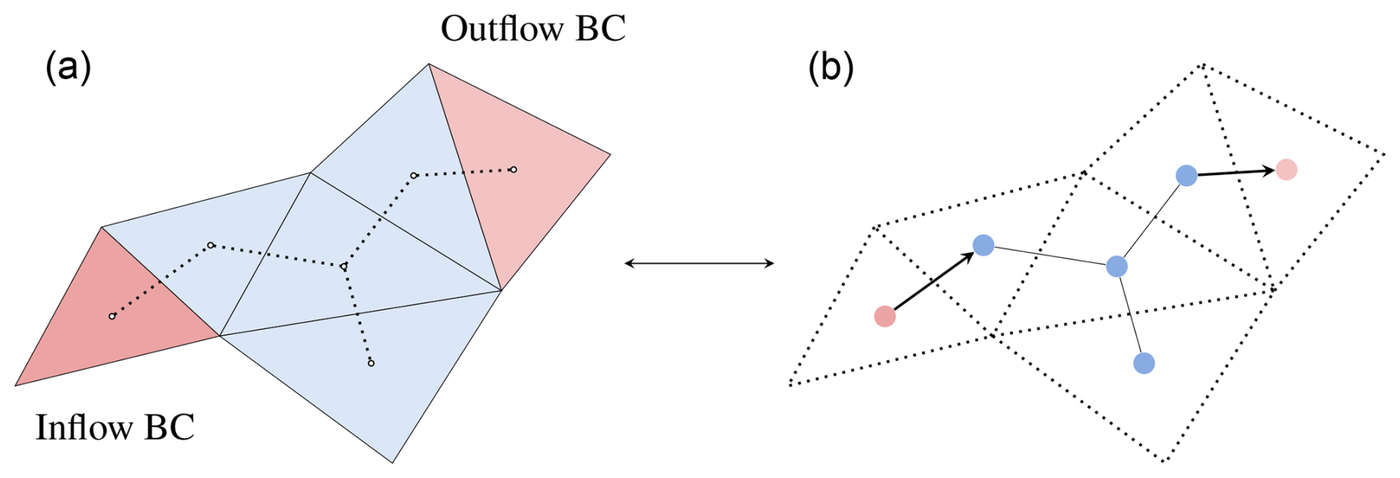

*Fig. 3 —* (a) A **ghost cell** (red) is added next to the boundary cell that receives a boundary condition: it belongs to the computational graph but not to the physical domain, and acts as the interface to the outside world. (b) In the dual graph an inflow boundary is a directed edge **from the ghost cell into the domain cell**, an outflow the other way round; wall boundaries get no ghost cell.

The discharge hydrograph $Q(t)$ [m³ s⁻¹] is first divided by the length of the edge it crosses, turning it into a unit discharge [m² s⁻¹] exactly as in the numerical method, and is then fed step by step as the ghost cell's dynamic feature; a water-level boundary simply imposes the known value on the ghost cell. **Time-varying boundary conditions** therefore enter message passing through the graph structure itself, which SWE-GNN could not do.

*Figure source: Bentivoglio et al., NHESS 25, 335–351, 2025, [doi:10.5194/nhess-25-335-2025](https://doi.org/10.5194/nhess-25-335-2025), CC BY 4.0.*

#### In the code / data: DEM, the inflow location matching the ghost cell, and the 20 test hydrographs
Left: the terrain (DEM) on the finest scale and the inflow location (red dot = the boundary cell that the ghost cell feeds). Right: the inflow hydrographs of the 20 test simulations.

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
m0 = mesh.meshes[0]
fine = slice(sample.node_ptr[0].item(), sample.node_ptr[1].item())
dem = sample.DEM[fine].cpu().numpy()
ax = plot_faces(m0, ax=axs[0], face_value=dem[:m0.num_faces], cmap="terrain", edgecolor="none")
plt.colorbar(ax.collections[-1], ax=axs[0], label="DEM [m]")
bc_face = int(sample.node_BC[0]) - sample.node_ptr[0].item()
axs[0].plot(m0.face_x[m0.face_BC], m0.face_y[m0.face_BC], "ro", ms=8, label="inflow boundary")
axs[0].set_aspect("equal"); axs[0].legend(); axs[0].set_title("test sim 0: DEM (finest scale)")
axs[0].set_xlabel("x [m]"); axs[0].set_ylabel("y [m]")

t_h = np.arange(sample.BC.shape[1]) * temporal_res / 60
for i, d in enumerate(test_dataset):
    axs[1].plot(t_h, d.BC[0].cpu().numpy() * d.edge_BC_length[0].item(), lw=1, alpha=0.7)
axs[1].set_xlabel("time [h]"); axs[1].set_ylabel("inflow discharge [m$^3$/s]"); axs[1].set_title("hydrographs of the 20 test simulations"); axs[1].grid()
plt.tight_layout()

### 2.4 Rotation-invariant inputs (§2.4)

The model's outputs ($h$, $|q|$) are scalars, so the authors deliberately **avoid every direction-dependent feature**: no $x/y$ components of the slope, no edge orientation, the dynamic input uses the **magnitude** of unit discharge rather than its vector components, and the only edge feature is the dual edge length. Rotating the whole input therefore leaves the output unchanged (rotation invariance), so the model does not have to learn rotational symmetry from the data and is more sample-efficient. The ablation (Table 3, "rotation-dependent inputs") shows that switching to direction-dependent inputs raises the test RMSE from 0.052 to 0.061 m.

### 2.5 Loss function and curriculum learning (§2.5, Appendix B, paper Fig. 13)

**Multi-step forecasting loss (Eq. 9)**

$$\mathcal{L}_f = \frac{1}{HO}\sum_{\tau=1}^{H}\sum_{o=1}^{O}\gamma_o\,\big\|\hat{u}^{t+\tau}_o - u^{t+\tau}_o\big\|^2,\qquad \gamma_1 = 1\ (h),\ \gamma_2 = 7\ (|q|)$$

- $H$ is the rollout length used in training, increased by **curriculum learning** from 1 step up to $H=6$ steps (12 h), which teaches the model to correct its own accumulating error;
- the code's `only_where_water` evaluates the loss only on wet cells, so the large dry areas do not dominate the gradient.

**Mass-conservation term (Appendix B, Eq. B1)**: $\mathcal{L}_c = \sum_i a_i\,\Delta\hat h_i - Q\,\Delta t$, i.e. the change of water volume inside the domain should equal the inflow volume; the total loss is $\mathcal{L} = \mathcal{L}_f + \alpha\,\mathcal{L}_c$.

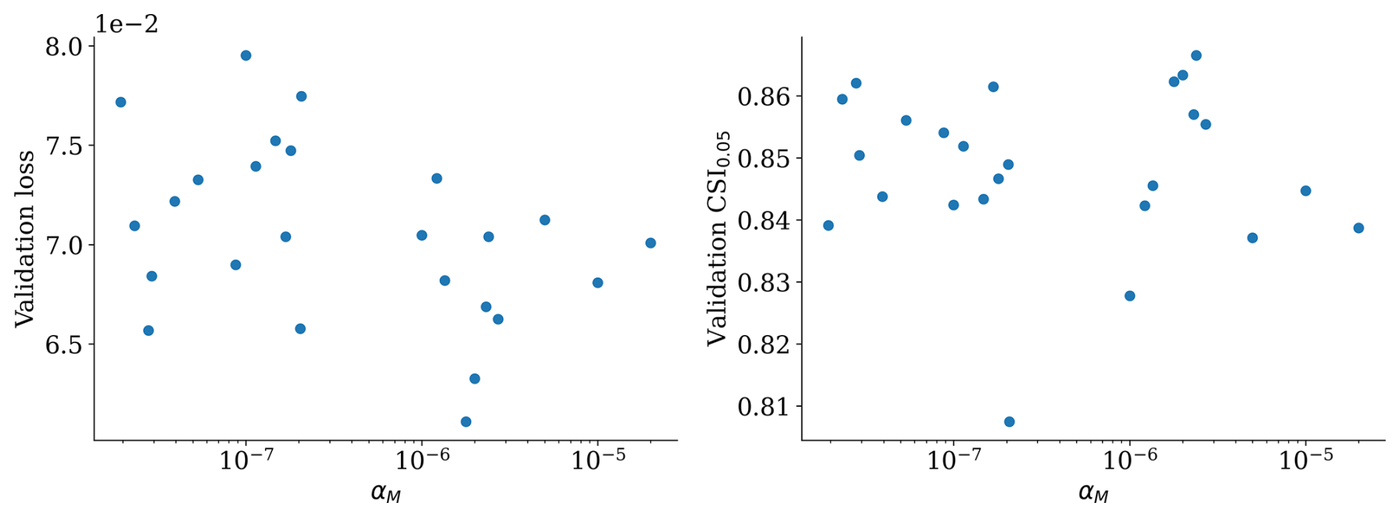

*Fig. 13 —* Sampling $\alpha_m$ log-uniformly in $[10^{-8}, 5\times10^{-5}]$ produced no statistically significant improvement in validation loss or CSI$_{0.05}$ ($p$ = 0.42 / 0.48), so the final model uses $\alpha = 0$ (bold in Table D1). The reproduction code in section 5 redraws this figure from `results/mass_conservation.csv`.

*Figure source: Bentivoglio et al., NHESS 25, 335–351, 2025, [doi:10.5194/nhess-25-335-2025](https://doi.org/10.5194/nhess-25-335-2025), CC BY 4.0.*

## 3. Experimental setup

### 3.1 Synthetic dataset (§3.1, paper Fig. 4, Fig. 6, Table 1)

- **Numerical model**: Delft3D FM (D-HYDRO Suite 1D2D), **100** dike-breach flood simulations: 60 train / 20 validation / 20 test.
- **Domain**: randomly generated ellipse-like polygons; the **DEM** is Perlin noise plus a small slope in a random direction; 4 mesh scales; spatially uniform Manning roughness of $0.023\ \mathrm{m^{-1/3}\,s}$.
- **Boundary condition**: an inflow hydrograph imposed on one random boundary edge, shaped like a Weibull density (right-tailed, as breach hydrographs are), with peaks of 150–300 m³ s⁻¹.
- **Time**: 2 h resolution over 96 h, i.e. 48 steps.

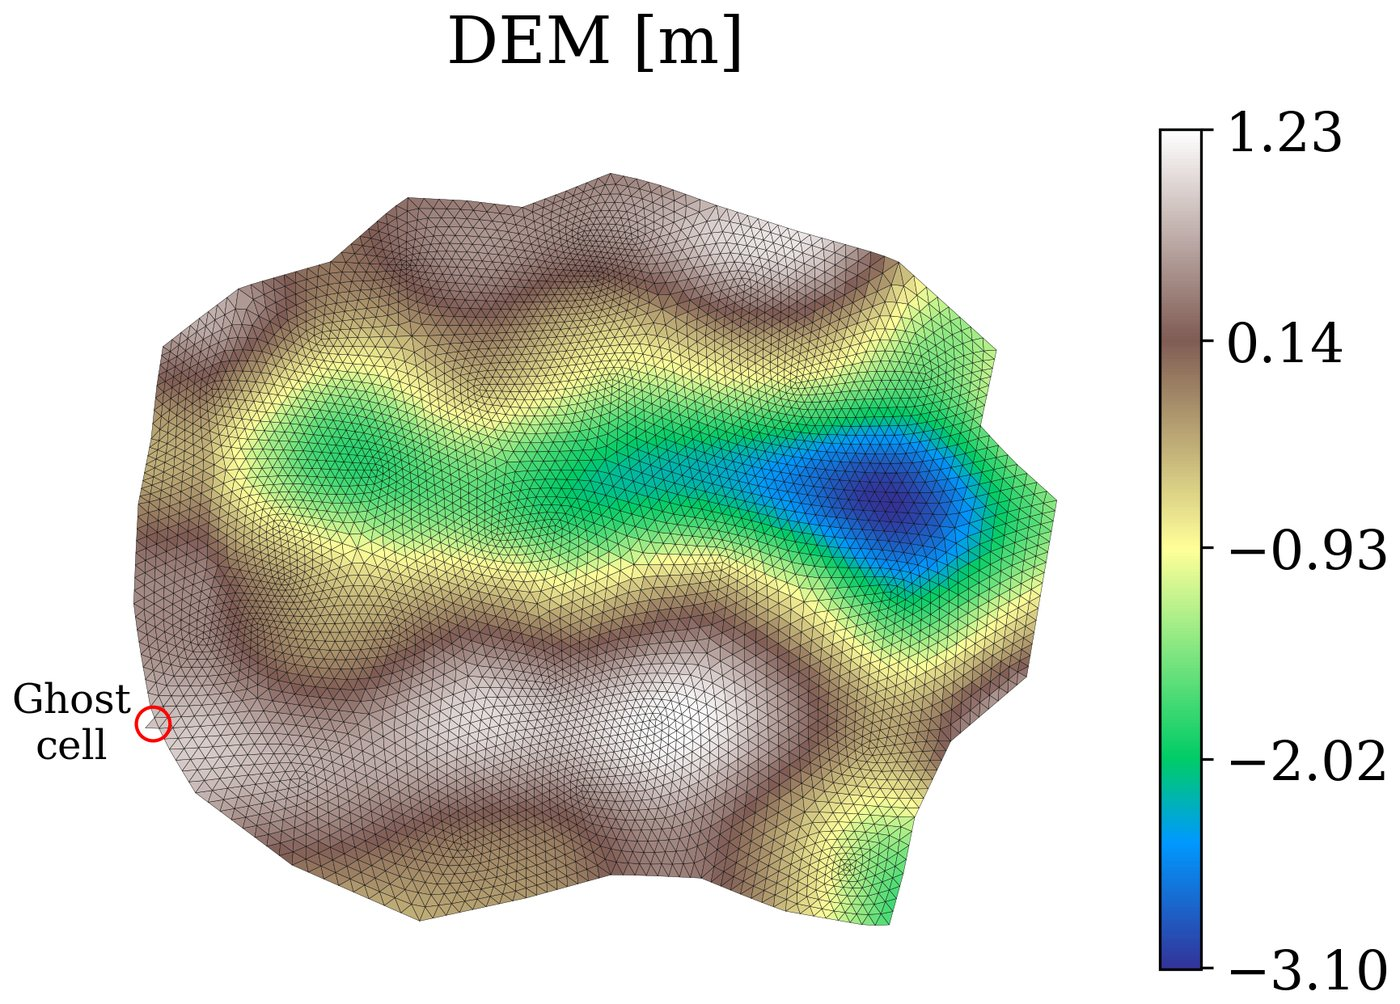

*Fig. 4 —* The finest mesh and DEM of one simulation in the synthetic dataset; the red circle on the left is the ghost cell (the inflow boundary). The elevation spans only about −3 to +1 m, i.e. nearly flat polder terrain.

**Table 1 — statistics of the training / validation / test sets (finest mesh, mean ± SD)**

| | Training | Validation | Testing |
|---|---|---|---|
| Elevation [m] | 0.07 ± 0.11 | 0.06 ± 0.10 | 0.07 ± 0.11 |
| Cells | 1621 ± 310 | 1608 ± 287 | 1650 ± 320 |
| Cell area [m²] | 1922 ± 1161 | 1957 ± 1210 | 1875 ± 1137 |
| Edge length [m] | 48.6 ± 16.2 | 49.2 ± 16.9 | 48.1 ± 15.8 |
| Total flood volume [10⁶ m³] | 0.71 ± 0.34 | 0.70 ± 0.31 | 0.72 ± 0.36 |

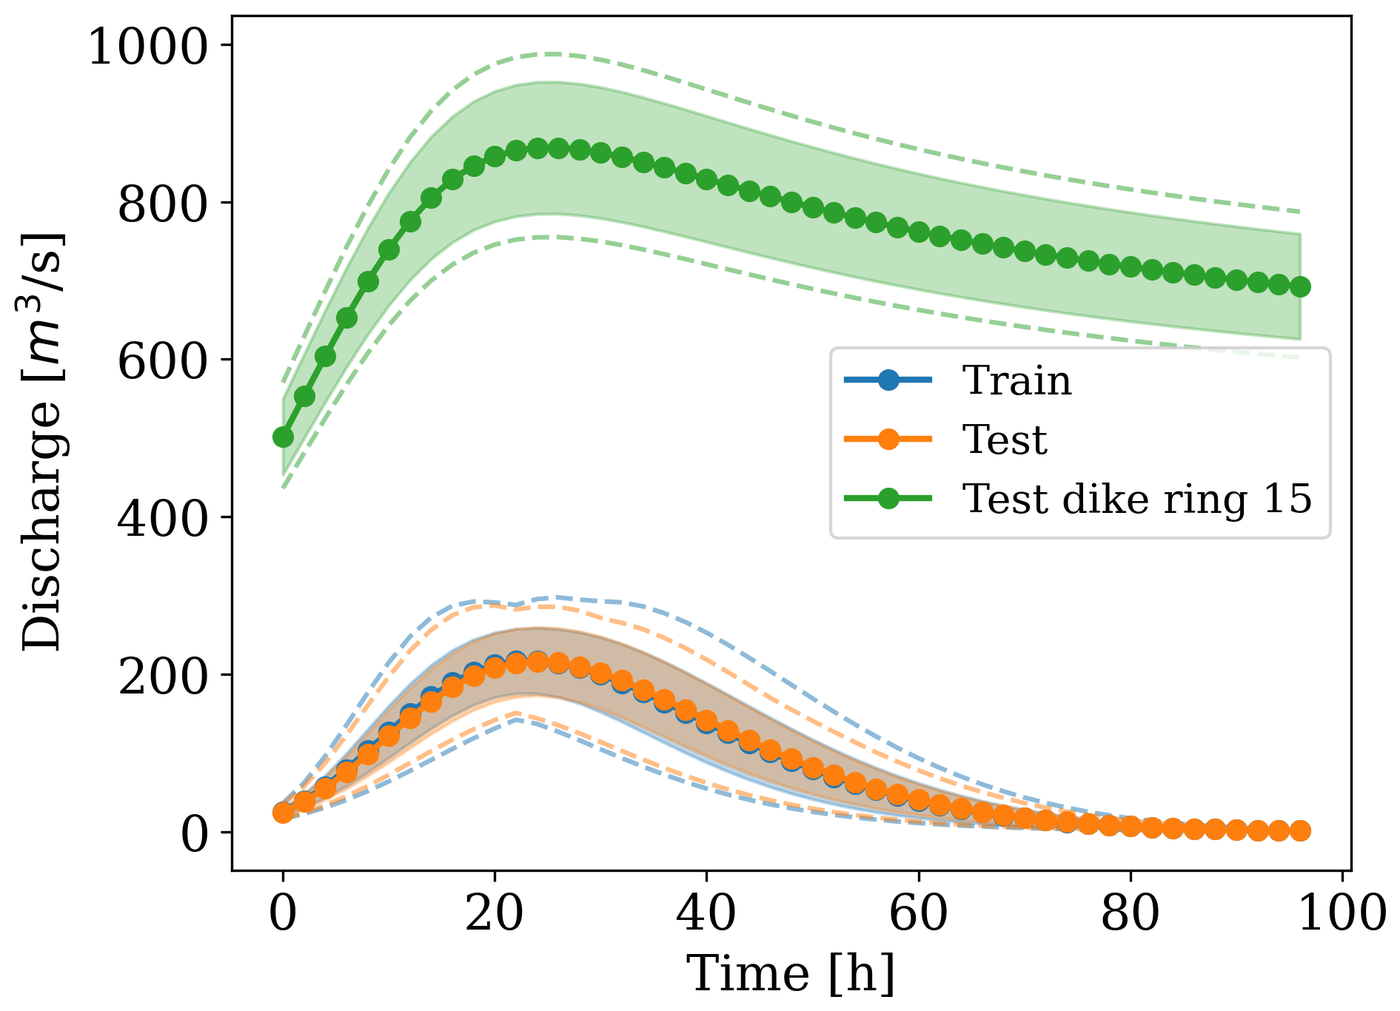

*Fig. 6 —* Mean ± 1 SD (dashed lines are the extremes) of the hydrographs used for training (blue), synthetic testing (orange) and dike-ring-15 testing (green). Training and synthetic testing share the same distribution; the dike-ring-15 discharges are 3–5× larger and do not return to zero (about 9× the total flood volume of the synthetic set), which makes it a genuinely **out-of-distribution** transfer case.

*Figure source: Bentivoglio et al., NHESS 25, 335–351, 2025, [doi:10.5194/nhess-25-335-2025](https://doi.org/10.5194/nhess-25-335-2025), CC BY 4.0.*

#### In the data: ground-truth water depth of test sim 0 over time

In [ ]:
times = [4, 12, 24, 48]   # indices at 120-min resolution -> 8 h, 24 h, 48 h, 96 h
fig, axs = plt.subplots(1, len(times), figsize=(5*len(times), 4.5))
WD_fine = sample.WD[fine].cpu().numpy()
vmax = WD_fine.max()
for ax, t in zip(axs, times):
    plot_faces(m0, ax=ax, face_value=WD_fine[:m0.num_faces, t], cmap="Blues", edgecolor="none", clim=(0, vmax))
    ax.set_aspect("equal"); ax.set_title(f"ground truth WD, t = {t*temporal_res/60:.0f} h"); ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(axs[-1].collections[-1], ax=axs, label="water depth [m]", shrink=0.8)

### 3.2 Real case study: dike ring 15 (§3.2, paper Fig. 5)

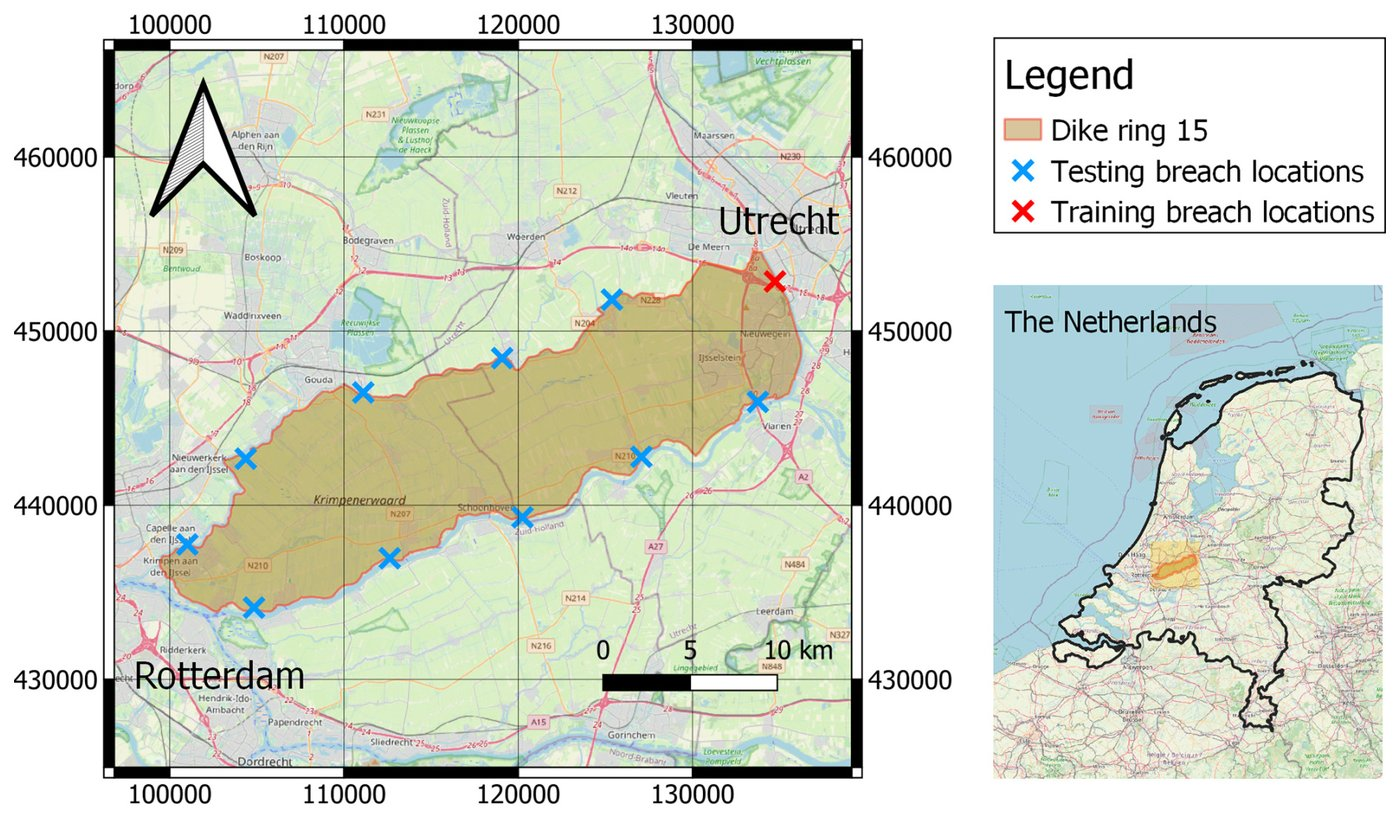

*Fig. 5 —* Dike ring 15 in the Netherlands (Krimpenerwaard–Lopikerwaard, between Rotterdam and Utrecht, EPSG:28992). It covers 31 400 ha, holds 201 500 inhabitants, and carries an expected flood damage of EUR 5.1 billion per event. Eleven roughly equidistant **breach locations** were selected along the ring: the red cross is the one used for fine-tuning (training + validation), the ten blue crosses are used for testing.

- Simplifications: all water bodies and every piece of infrastructure not already in the DEM were removed, and roughness is uniform.
- Hydrographs: a rising limb (the breach widening) followed by a slow decline that ends at non-zero discharge, peaking at 700–1000 m³ s⁻¹.
- Mesh: 22 880 cells on the finest scale (about 30 000 nodes per sample in the code, see section 4.2); depending on the breach location, the basin responds either like a bathtub or like a slope.

*Figure source: Bentivoglio et al., NHESS 25, 335–351, 2025, [doi:10.5194/nhess-25-335-2025](https://doi.org/10.5194/nhess-25-335-2025), CC BY 4.0.*

### 3.3 Normalisation (§3.3)

Only **cell area** and **edge length** are z-scored, and the mean/variance are computed **separately for each scale** using the training set (coarse cells are orders of magnitude larger, so pooling all scales into one statistic would be meaningless). Every other variable (elevation, water depth, discharge) is left untouched. This is `config.scalers` in the code, fitted on the training set by `create_model_dataset` — in this notebook it is only used to transform the test data.

### 3.4 Training setup (§3.4, paper Table D1)

| Item | Value |
|---|---|
| Framework | PyTorch 2.0.1 + PyTorch Geometric 2.4; NVIDIA A100 80 GB |
| Optimiser / learning rate | Adam, initial 0.003, ×0.7 every 20 epochs |
| Epochs | 200 with early stopping; 16-bit mixed precision; gradient clipping at 1 |
| Curriculum learning | training rollout length raised gradually to $H=6$ |
| Training time | mSWE-GNN 2–15 h, SWE-GNN 5–30 h; dike-ring-15 fine-tuning about 20 min (5 min with fewer epochs) |

**Table D1 — hyperparameter ranges (bold = best validation loss)**

| DL model | Hyperparameter | Values' range (**best**) |
|---|---|---|
| All models | Initial learning rate | 0.003 |
| | Input previous time steps ($p$) | 2 |
| | Maximum training steps ahead ($H$) | 6 |
| | Optimizer | Adam |
| | Batch size | 12 |
| | $\alpha$ (mass-conservation weight) | **0**, $[10^{-8}, 5\times10^{-5}]$ |
| SWE-GNN | Embedding dimension ($G$) | 16, 32, 50, **64** |
| | Number of GNN layers ($L$) | 10, 12, 14, **16**, 18 |
| mSWE-GNN | Embedding dimension ($G$) | 16, 32, 50, **64** |
| | Number of GNN layers ($L$, per scale) | 2, 3, **4**, 5 |

Mapping onto the repo: `results/Pareto_front/models/K{L}_F{G}.h5` is exactly this 4 × 4 = 16-model grid for mSWE-GNN; in `config.yaml`, `models.K` is $L$ and `models.hid_features` is $G$.

#### In the code: load the pretrained `K4_F64` and roll it out (no training in this notebook)
- Build an `MSGNN` with the same hyperparameters as the checkpoint (hid 64, K 4, 4 scales, 811 309 parameters) and load the weights through `LightningTrainer.load_from_checkpoint`.
- Rollout: starting from a dry bed at t=0, the model uses only its own previous prediction plus the inflow boundary and advances 47 steps (94 h) autoregressively. This is how the paper evaluates, i.e. not teacher forcing.

In [ ]:
def build_model(config, sample_data, previous_t):
    model_parameters = copy(dict(config.models))
    model_type = model_parameters.pop("model_type")
    if model_type == "MSGNN":
        model_parameters["num_scales"] = sample_data.mesh.num_meshes
    tmp = to_temporal(sample_data, rollout_steps=-1, **temporal_test_dataset_parameters)[0]
    model = get_model(model_type)(num_node_features=tmp.x.size(-1), num_edge_features=tmp.edge_attr.size(-1),
                                  previous_t=previous_t, device=device, **model_parameters).to(device)
    return model

def load_plmodule(ckpt_path, config, sample_data):
    model = build_model(config, sample_data, previous_t)
    kw = dict(model=model, lr_info=config["lr_info"], trainer_options=config.trainer_options,
              temporal_test_dataset_parameters=temporal_test_dataset_parameters)
    plm = LightningTrainer.load_from_checkpoint(ckpt_path, map_location=device, **kw)
    plm.model.to(device).eval()
    return plm

def run_rollout(plm, dataset, batch_size=20):
    dataset = [d.to(device) for d in dataset]   # SpatialAnalysis moves Data objects to CPU in place -> move all back
    temporal = to_temporal_dataset(dataset, rollout_steps=-1, **temporal_test_dataset_parameters)
    loader = DataLoader(temporal, batch_size=batch_size, shuffle=False)
    trainer = L.Trainer(accelerator="auto", devices=1, logger=False, enable_progress_bar=False)
    if device.type == "cuda": torch.cuda.synchronize()
    t0 = time.time()
    pred = trainer.predict(plm, dataloaders=loader)
    if device.type == "cuda": torch.cuda.synchronize()
    per_sim_time = (time.time() - t0) / len(temporal)
    pred = [item for roll in pred for item in roll]
    return pred, per_sim_time

MAIN_CKPT = config.saved_model
plmodule = load_plmodule(MAIN_CKPT, config, test_dataset[0])
model = plmodule.model
print(MAIN_CKPT, "| parameters:", sum(p.numel() for p in model.parameters()))

predicted_rollout, prediction_time = run_rollout(plmodule, test_dataset)
print(f"rollout of {len(test_dataset)} simulations x {predicted_rollout[0].shape[-1]} steps: {prediction_time:.2f} s per simulation on {device}")

### 3.5 Metrics (§3.5)

- **MAE / RMSE** (Eq. 10): the error over the whole rollout, per cell and per time step, computed separately for water depth $h$ and unit discharge $|q|$.
- **CSI** (critical success index, Eq. 11): $\mathrm{CSI}=\dfrac{TP}{TP+FP+FN}$, obtained by thresholding prediction and ground truth at 0.05 m ("flooded or not") and 0.3 m ("dangerous depth or not"); 1 means the flood extent matches exactly.
- **Speed-up**: numerical model runtime divided by deep-learning inference time; the deep-learning model is run **in parallel** over all test simulations (Appendix C discusses the effect of batch size).

**Conventions used in this notebook:**
- **test roll loss WD / V**: the **RMSE** of water depth and unit discharge over the whole rollout (the quantity `main.py` logs to wandb / csv). Note that `test_model.py` prints the **MAE** instead; the two are not comparable, so the table below reports both.
- **CSI$_{0.05}$ / CSI$_{0.3}$**: critical success index, treating depths > 0.05 m / 0.3 m as flooded, measuring the overlap between predicted and true flood extent (1 = perfect).
- **speed-up**: the ratio between the D-HYDRO runtime (`database/overview.csv`) and the model's rollout time.

The comparison rows come from `results/Pareto_front/overview_MSGNN.csv` shipped with the repo (the values the authors logged to wandb during training).

## 4. Results

### 4.1 Synthetic test set: comparison with SWE-GNN (§4.1)

#### 4.1.1 In the code: global metrics for `K4_F64` against the repo's `overview_MSGNN.csv`

In [ ]:
maximum_time = test_dataset[0].WD.shape[1]
numerical_times = get_numerical_times(test_dataset_name + "_test", len(test_dataset), temporal_res, maximum_time,
                                      **temporal_test_dataset_parameters, overview_file="database/overview.csv")
spatial_analyser = SpatialAnalysis(predicted_rollout, prediction_time, test_dataset, **temporal_test_dataset_parameters)

def summarise(sa, type_loss="RMSE"):
    rl = sa._get_rollout_loss(type_loss=type_loss)
    mae = sa._get_rollout_loss(type_loss="MAE")
    speed, speed_std = get_speed_up(numerical_times, sa.prediction_times)
    return {"test roll loss WD": rl.mean(0)[0].item(), "test roll loss V": rl.mean(0)[1:].mean().item(),
            "MAE WD (test_model.py metric)": mae.mean(0)[0].item(), "MAE V": mae.mean(0)[1:].mean().item(),
            "test CSI_005": sa._get_CSI(water_threshold=0.05).nanmean().item(),
            "test CSI_03": sa._get_CSI(water_threshold=0.3).nanmean().item(),
            "speed-up": float(speed), "speed-up std": float(speed_std)}

res_main = summarise(spatial_analyser)
ov = pd.read_csv("results/Pareto_front/overview_MSGNN.csv")
ref = ov[(ov["models.K"] == config.models["K"]) & (ov["models.hid_features"] == config.models["hid_features"])].iloc[0]
cmp = pd.DataFrame({"this run (GPU, rebuilt pickles)": res_main,
                    "repo overview_MSGNN.csv": {k: ref.get(k, np.nan) for k in res_main}})
cmp.round(4)

#### 4.1.2 How the metrics evolve over the rollout (paper Fig. 8)

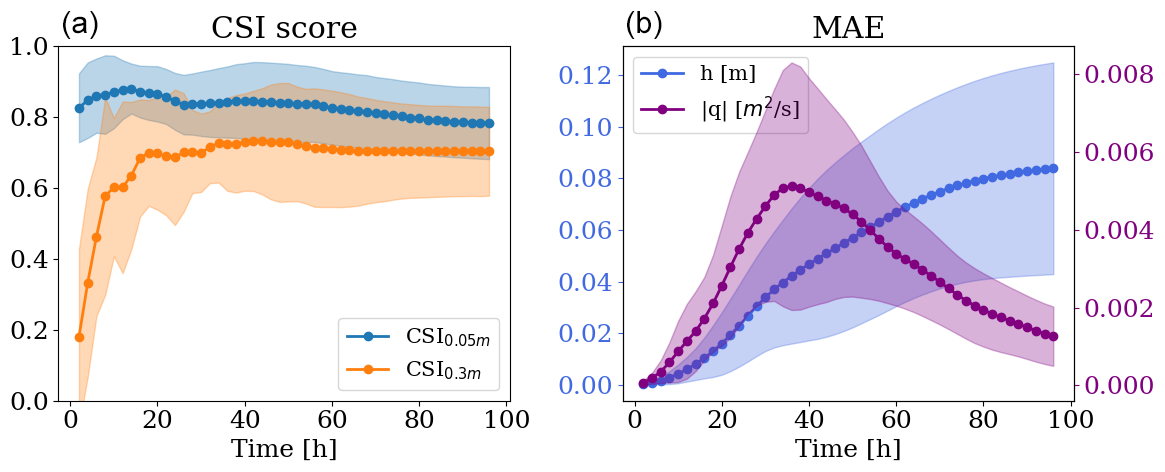

*Fig. 8 —* On the synthetic test set: (a) CSI$_{0.05}$ / CSI$_{0.3}$ and (b) the MAE of $h$ and $|q|$ as a function of lead time (shaded band = ±1 SD). CSI$_{0.05}$ stays above 0.78 across all 48 steps; CSI$_{0.3}$ is low over the first 20 h because the deep-water area is still small, so a few cells dominate the score. The depth MAE grows monotonically (autoregressive error accumulation), while the discharge MAE peaks around the flood peak and falls back as the inflow subsides. The cell below reproduces both panels with `SpatialAnalysis`.

*Figure source: Bentivoglio et al., NHESS 25, 335–351, 2025, [doi:10.5194/nhess-25-335-2025](https://doi.org/10.5194/nhess-25-335-2025), CC BY 4.0.*

##### In the code: CSI and MAE over the rollout
Left: CSI as a function of lead time (shaded = standard deviation over the 20 simulations). Right: how the depth and discharge errors accumulate.

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
_, CSI = spatial_analyser.plot_CSI_rollouts(water_thresholds=[0.05, 0.3], ax=axs[0])
_ = spatial_analyser._plot_rollouts(type_loss="MAE", ax=axs[1])
axs[0].grid(False); plt.tight_layout()

#### 4.1.3 In the code: per-simulation error ranking
`plot_loss_per_simulation` sorts the 20 test simulations by RMSE and shows each one's CSI alongside; it returns the sorted ids, which we use to pick the best and worst cases.

In [ ]:
sorted_ids = spatial_analyser.plot_loss_per_simulation(type_loss="RMSE", ranking="loss", only_where_water=False, water_thresholds=[0.05, 0.3])
rollout_loss = spatial_analyser._get_rollout_loss(type_loss="RMSE")
best_id, worst_id = rollout_loss.mean(1).argmin().item(), rollout_loss.mean(1).argmax().item()
print("best simulation id:", best_id, "| worst simulation id:", worst_id)

#### 4.1.4 In the code: visualising a single simulation
`PlotRollout.explore_rollout` is the authors' summary figure: DEM, ground-truth/predicted/error water-depth maps, discharge maps, and the error over time (`scale=0` is the finest mesh). We look at the lowest-error simulation first, then the highest.

In [ ]:
rollout_plotter = PlotRollout(model.to(device), test_dataset[best_id].to(device), scalers=scalers, type_loss="RMSE", **temporal_test_dataset_parameters)
rollout_plotter.plot_BC();
fig = rollout_plotter.explore_rollout(time_step=-1, scale=0, logscale=True)
fig.suptitle(f"BEST test simulation (id {best_id}) at the end of the rollout", y=1.02);

In [ ]:
rollout_plotter_w = PlotRollout(model.to(device), test_dataset[worst_id].to(device), scalers=scalers, type_loss="RMSE", **temporal_test_dataset_parameters)
fig = rollout_plotter_w.explore_rollout(time_step=-1, scale=0, logscale=True)
fig.suptitle(f"WORST test simulation (id {worst_id}) at the end of the rollout", y=1.02);

##### Water depth and discharge at selected times (best simulation)
One row per time (8 h / 24 h / 48 h / 94 h): ground truth · prediction · difference.

In [ ]:
plot_times = [4, 12, 24, 46]
rollout_plotter.compare_h_rollout(plot_times, scale=0)
rollout_plotter.compare_v_rollout(plot_times, scale=0, logscale=True)

##### The matching figure in the paper: unit-discharge rollout on the synthetic test set (Appendix A, paper Fig. 12)

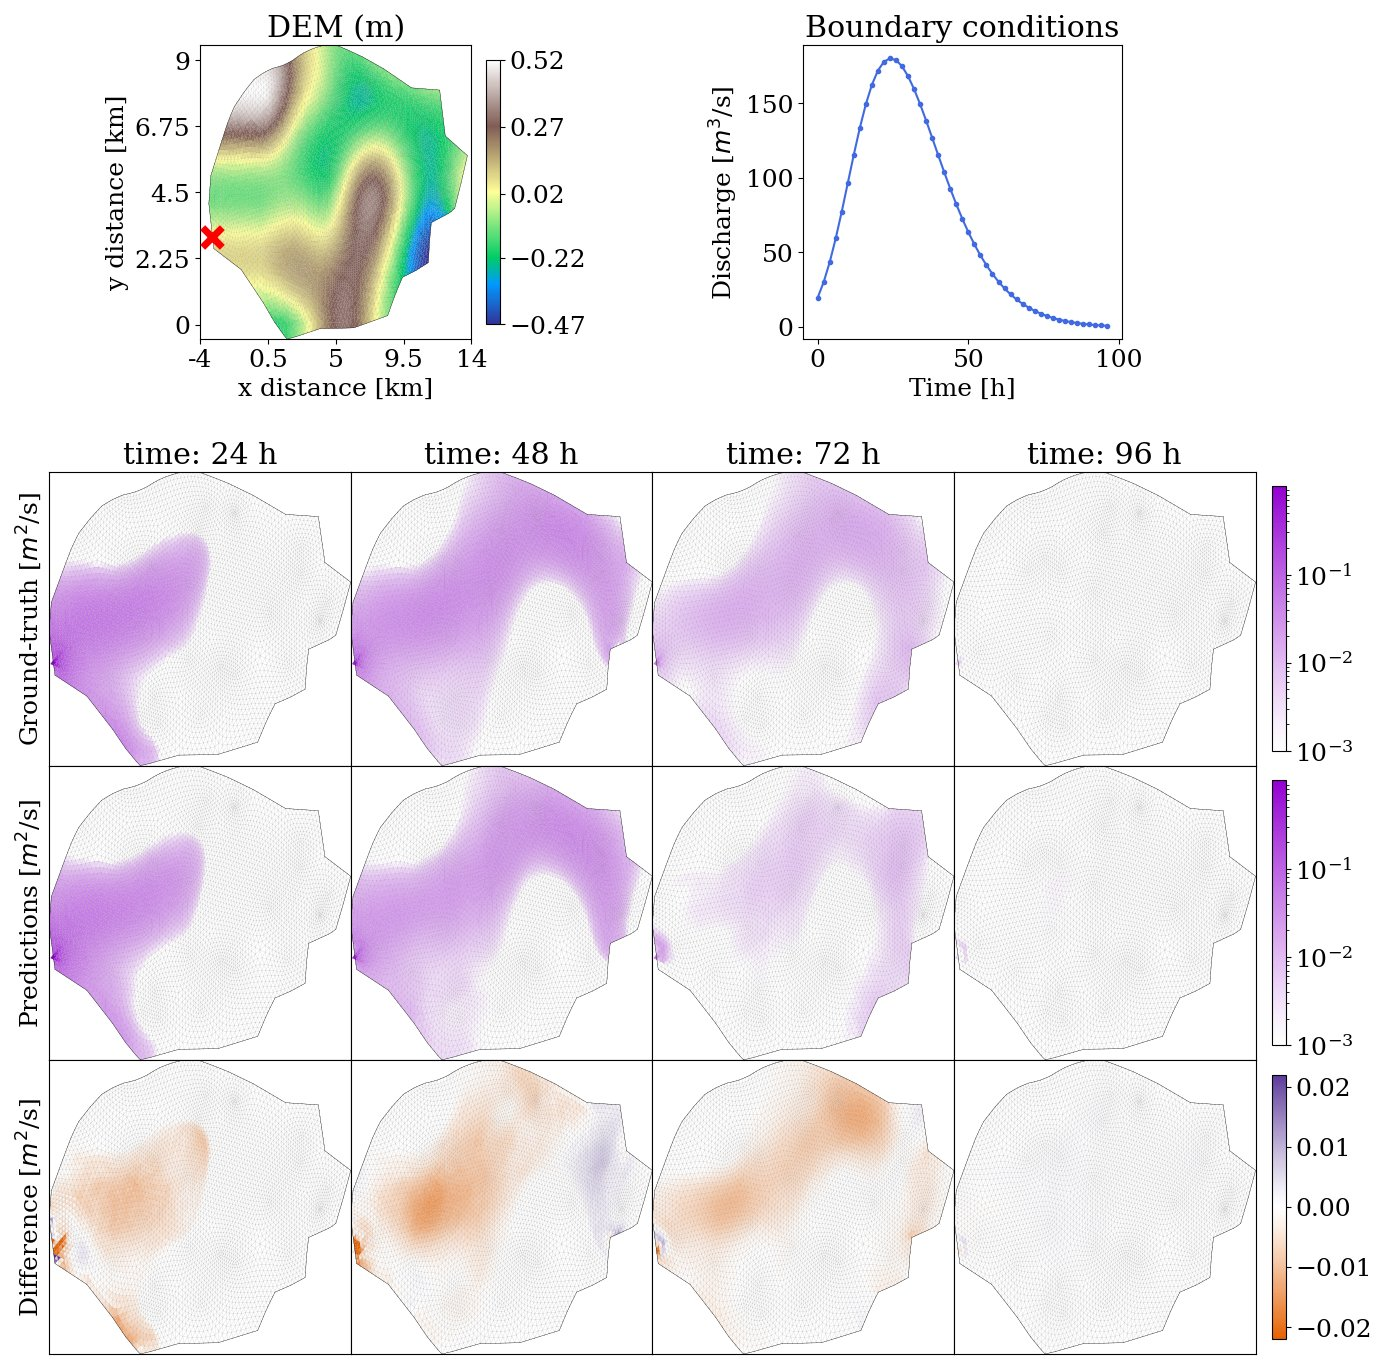

*Fig. 12 —* $|q|$ for one synthetic test simulation on a logarithmic colour scale: ground truth (top), prediction (middle), difference (bottom). The model reproduces how the flood front advances into the domain and then recedes as the inflow weakens; the largest errors sit near the breach and along the path of the flood peak around 48 h, at a magnitude of 0.02 m² s⁻¹. The `compare_v_rollout` call above draws the same kind of figure.

*Figure source: Bentivoglio et al., NHESS 25, 335–351, 2025, [doi:10.5194/nhess-25-335-2025](https://doi.org/10.5194/nhess-25-335-2025), CC BY 4.0.*

##### Flood arrival time (FAT) and mass conservation
FAT is the time at which each cell first exceeds 0.05 m of water depth, one of the quantities emergency planners care about most. The mass-conservation plot compares the cumulative inflow volume with the water volume inside the domain.

In [ ]:
rollout_plotter.compare_FAT(water_threshold=0.05, scale=0)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
rollout_plotter._plot_mass_conservation(normalized=True, with_cum=True, ax=ax)
ax.set_title(f"mass conservation, test sim {best_id}")

##### The multi-scale view
Predicted water depth on all four scales at the same instant (the model also maintains a water field on the coarse scales, which is what carries information across scales).

In [ ]:
fig = rollout_plotter.explore_multiscale_rollout(time_step=-1, variable="WD", logscale=True)

#### 4.1.5 Pareto front: speed versus accuracy (paper Fig. 7, Table A1)

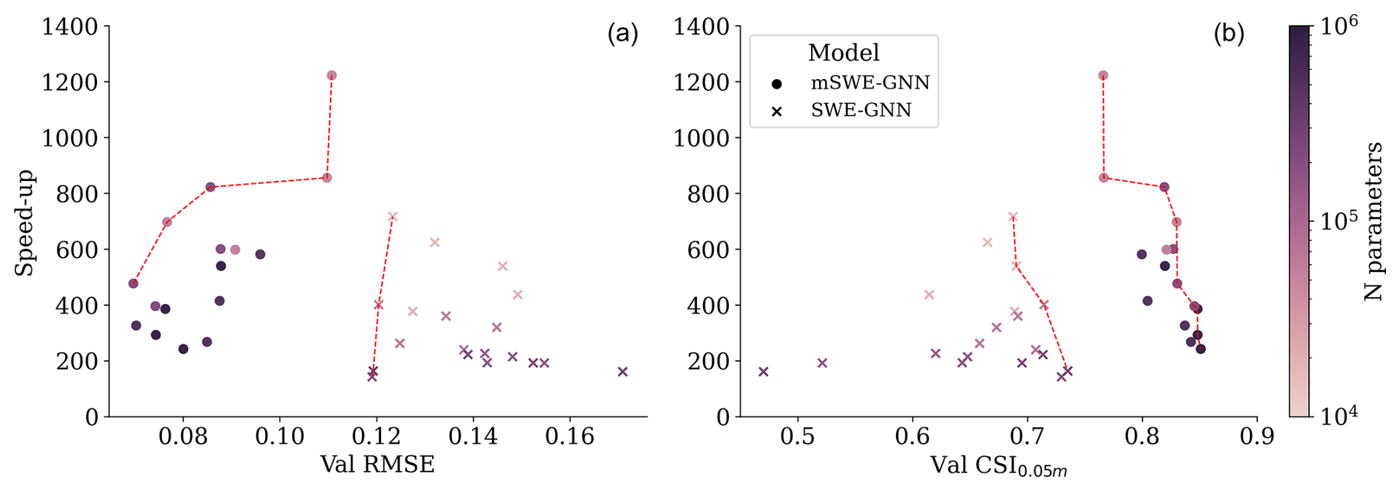

*Fig. 7 —* mSWE-GNN (circles) and SWE-GNN (crosses) in the plane of speed-up against (a) validation RMSE and (b) validation CSI$_{0.05}$; colour is the parameter count and the dashed red line is each model's Pareto front. The key points:
- the mSWE-GNN Pareto front **dominates** SWE-GNN's — 2–4× faster at equal accuracy, and about 0.04 m lower RMSE at equal speed;
- the fastest mSWE-GNN variant exceeds a **1200×** speed-up; it does not have fewer parameters than SWE-GNN, but it runs only **2–5 layers on the finest scale** (the one with most nodes and edges) whereas SWE-GNN needs 10–18, and that is where the compute difference comes from;
- fewer layers also make training more stable (gap 2). The reference model selected in the paper is $L=4, G=64$, a compromise between speed and accuracy.

**Table A1 — runtimes and speed-ups (the selected model)**

| Dataset | Numerical model | mSWE-GNN | Speed-up |
|---|---|---|---|
| Synthetic test set (20 sims) | 12 h 20 min | 0.61 ± 0.02 s | 728 ± 32 |
| Dike ring 15 (10 sims) | 47 h 15 min | 0.24 ± 0.01 s | 708 ± 24 |

Below we roll out each of the 16 checkpoints shipped with the repo and rebuild this Pareto figure (the paper uses the validation set, we use the test set).

*Figure source: Bentivoglio et al., NHESS 25, 335–351, 2025, [doi:10.5194/nhess-25-335-2025](https://doi.org/10.5194/nhess-25-335-2025), CC BY 4.0.*

##### In the code: reproducing the Pareto front over 16 checkpoints (K ∈ {2,3,4,5} × F ∈ {16,32,50,64})
The paper draws a Pareto front for a family of models in the speed-versus-accuracy plane. Here each checkpoint is rolled out again and plotted next to the values recorded in the repo.
Set `RUN_ALL_CHECKPOINTS=False` to skip this (each model takes several minutes on CPU).

In [ ]:
# RUN_ALL_CHECKPOINTS = True    # full notebook: 16 checkpoints x 20 sims, ~3.5 h on CPU
# ---------------- FAST VARIANT ----------------------------------------------------
# Skipped. df_pf becomes None, and both cells below are guarded by `if df_pf is not None`,
# so the Pareto figure is still drawn from the authors' recorded overview_MSGNN.csv.
RUN_ALL_CHECKPOINTS = False
# ----------------------------------------------------------------------------------
records = []
if RUN_ALL_CHECKPOINTS:
    for ck in sorted(glob.glob("results/Pareto_front/models/K*_F*.h5")):
        K = int(os.path.basename(ck)[1]); F = int(os.path.basename(ck).split("_F")[1].split(".")[0])
        cfg_k = read_config(CFG_FILE); cfg_k["models"]["K"] = K; cfg_k["models"]["hid_features"] = F
        wandb.finish(); wandb.init(mode="disabled", config=cfg_k); fix_dict_in_config(wandb); config_k = wandb.config
        try:
            plm_k = load_plmodule(ck, config_k, test_dataset[0])
            pred_k, t_k = run_rollout(plm_k, test_dataset)
            sa_k = SpatialAnalysis(pred_k, t_k, test_dataset, **temporal_test_dataset_parameters)
            r = summarise(sa_k); r.update({"K": K, "F": F, "params": sum(p.numel() for p in plm_k.model.parameters()), "ckpt": os.path.basename(ck)})
            records.append(r); print(f"{os.path.basename(ck):12s} CSI_005 {r['test CSI_005']:.3f}  CSI_03 {r['test CSI_03']:.3f}  WD {r['test roll loss WD']:.4f}  speed-up {r['speed-up']:.0f}")
            del plm_k, pred_k, sa_k; torch.cuda.empty_cache()
        except Exception as e:
            print(f"{ck}: FAILED {type(e).__name__}: {e}")
    wandb.finish(); wandb.init(mode="disabled", config=cfg); fix_dict_in_config(wandb); config = wandb.config
df_pf = pd.DataFrame(records).set_index("ckpt") if records else None
df_pf.round(4) if df_pf is not None else "skipped"

In [ ]:
ov_ms = pd.read_csv("results/Pareto_front/overview_MSGNN.csv"); ov_gnn = pd.read_csv("results/Pareto_front/overview_GNN.csv")
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axs, ["test CSI_005", "test roll loss WD"]):
    ax.scatter(ov_gnn["speed-up"], ov_gnn[metric], c="gray", marker="s", label="SWE-GNN (repo csv)")
    sc = ax.scatter(ov_ms["speed-up"], ov_ms[metric], c=ov_ms["models.hid_features"], cmap="viridis", marker="o", s=60, label="mSWE-GNN (repo csv)")
    for _, r in ov_ms.iterrows(): ax.annotate(f"K{int(r['models.K'])}F{int(r['models.hid_features'])}", (r["speed-up"], r[metric]), fontsize=7, alpha=0.7)
    if df_pf is not None:
        ax.scatter(df_pf["speed-up"], df_pf[metric], facecolors="none", edgecolors="red", s=90, lw=1.5, label="mSWE-GNN (this notebook)")
    ax.set_xscale("log"); ax.set_xlabel("speed-up vs D-HYDRO (log)"); ax.set_ylabel(metric); ax.grid(True, which="both", alpha=0.3)
axs[0].legend(); plt.colorbar(sc, ax=axs[1], label="hidden features F"); axs[0].set_title("accuracy (CSI 0.05 m)"); axs[1].set_title("water-depth RMSE")
plt.tight_layout()

In [ ]:
if df_pf is not None:
    m = df_pf.reset_index().merge(ov_ms, left_on=["K", "F"], right_on=["models.K", "models.hid_features"], suffixes=(" (nb)", " (csv)"))
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
    for ax, k in zip(axs, ["test CSI_005", "test CSI_03", "test roll loss WD"]):
        ax.scatter(m[k + " (csv)"], m[k + " (nb)"], c=m["K"], cmap="tab10", s=50)
        lim = [min(m[k + " (csv)"].min(), m[k + " (nb)"].min()), max(m[k + " (csv)"].max(), m[k + " (nb)"].max())]
        ax.plot(lim, lim, "k--", lw=1); ax.set_xlabel(k + " — repo csv"); ax.set_ylabel(k + " — this notebook"); ax.grid(alpha=0.3)
        for _, r in m.iterrows(): ax.annotate(f"K{r['K']}F{r['F']}", (r[k + " (csv)"], r[k + " (nb)"]), fontsize=7)
    fig.suptitle("re-evaluated checkpoints vs. values recorded in the repo (points on the diagonal = exact reproduction)")
    plt.tight_layout()
    print("mean |Δ CSI_005| =", (m["test CSI_005 (nb)"] - m["test CSI_005 (csv)"]).abs().mean().round(4),
          "| mean |Δ WD RMSE| =", (m["test roll loss WD (nb)"] - m["test roll loss WD (csv)"]).abs().mean().round(4))

### 4.2 Transfer to the real case study: dike ring 15 (§4.2, paper Fig. 9–11, Table 2)

Applied directly to dike ring 15, a model trained only on the synthetic data reaches a CSI$_{0.05}$ of just 63 % (the hydrographs are out of distribution, see Fig. 6). After fine-tuning on a **single** simulation for about 20 min, the CSI$_{0.05}$ over the 10 test breaches rises to **87.68 %** and the depth MAE falls from 0.31 m to 0.12 m.

**Table 2 — effect of fine-tuning (10 test simulations, mean ± SD, finest mesh)**

| Fine-tuning | MAE $h$ [10⁻² m] ↓ | MAE $\lvert q\rvert$ [10⁻² m² s⁻¹] ↓ | CSI$_{\tau=0.05\,\mathrm{m}}$ [%] ↑ | CSI$_{\tau=0.3\,\mathrm{m}}$ [%] ↑ |
|---|---|---|---|---|
| No | 31.09 ± 5.42 | 3.37 ± 1.24 | 63.36 ± 19.54 | 46.06 ± 18.62 |
| Yes | **12.07 ± 4.19** | **2.08 ± 0.82** | **87.68 ± 10.3** | **81.82 ± 16.07** |

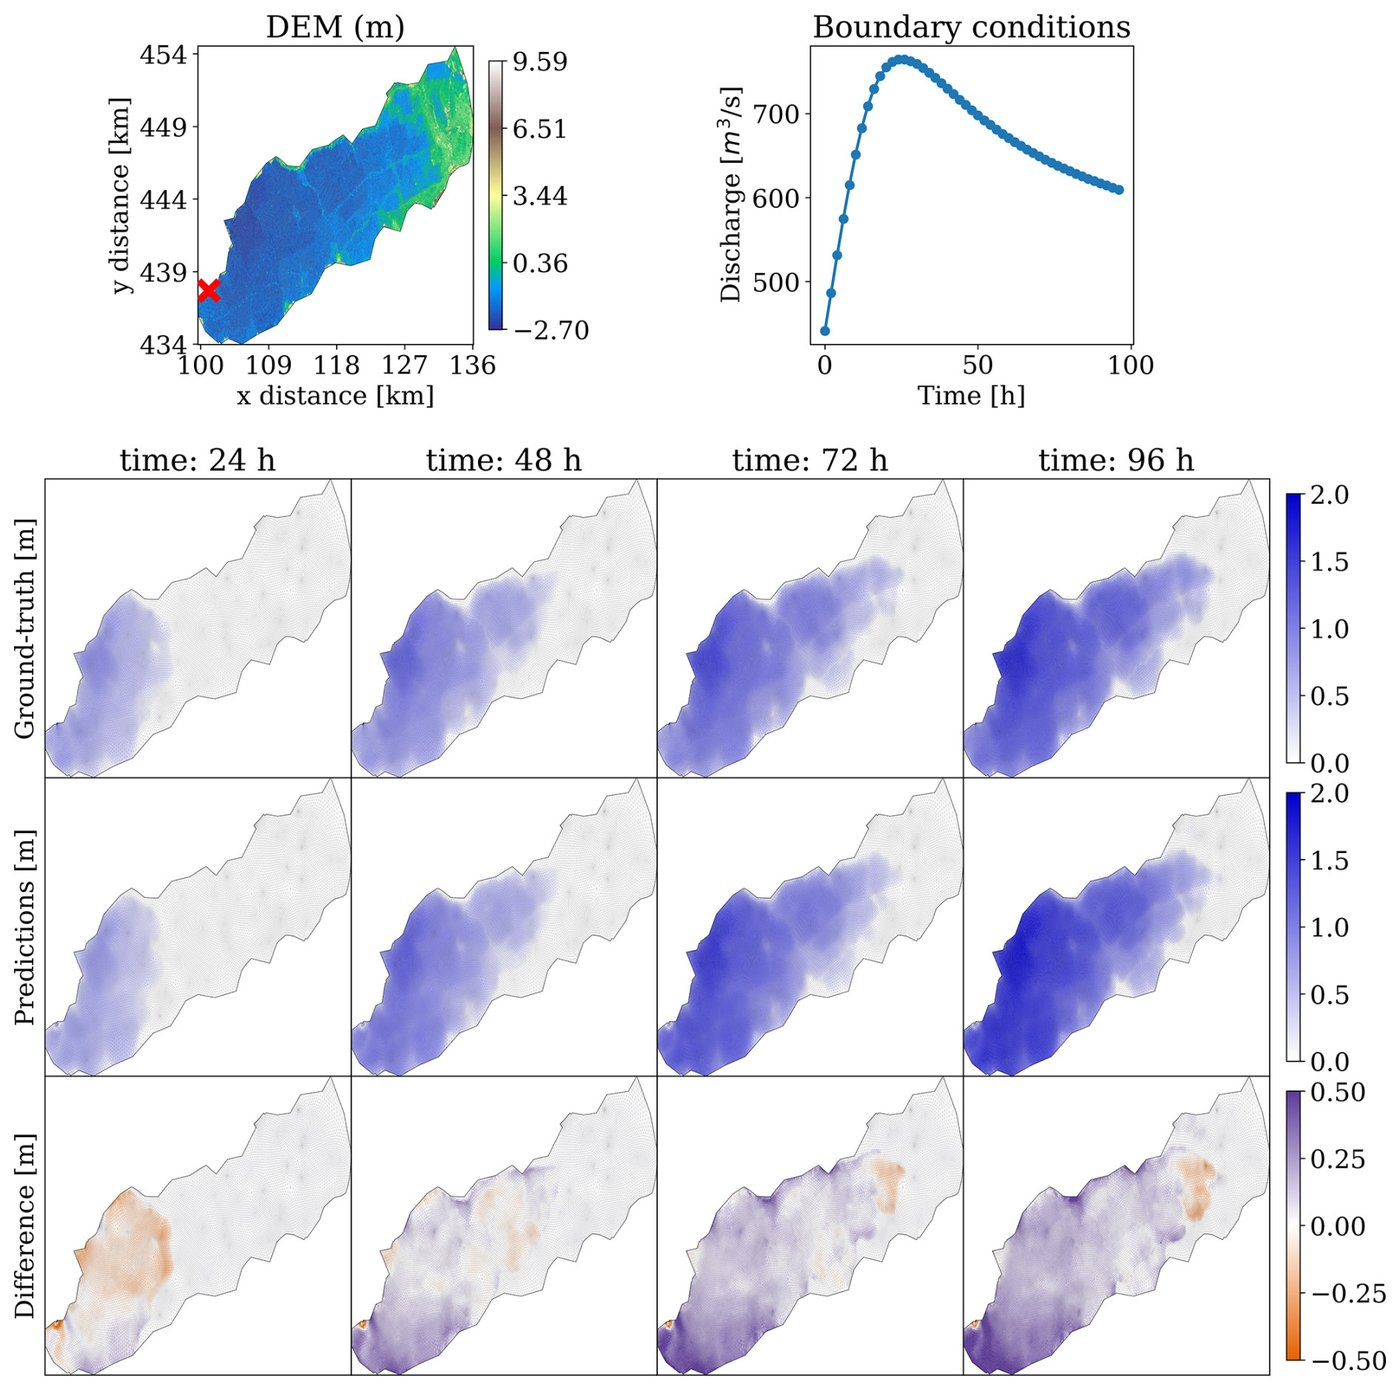

*Fig. 9 —* Water-depth rollout for one dike-ring-15 test breach (red cross, top left): ground truth (top), prediction (middle), difference (bottom). The model captures the overall dynamics of the flood spreading north-east across the low polder; the errors are mainly a systematic slight overestimate after 48 h (purple) and a local underestimate near the breach.

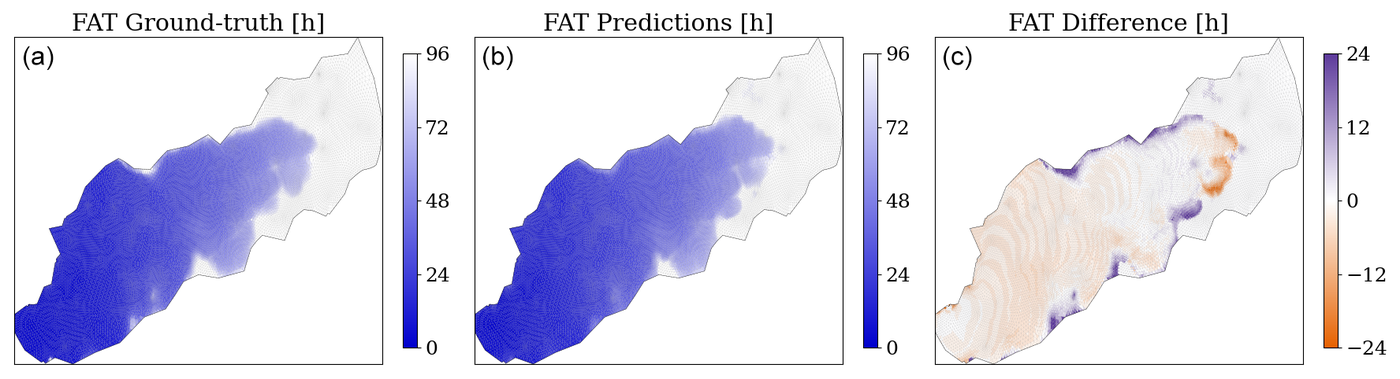

*Fig. 10 —* Flood arrival time for the same simulation (the moment each cell first exceeds 0.05 m). The predicted arrival-time field is nearly identical to the ground truth, with the differences concentrated at the tail of the flood front (±12–24 h). FAT is the quantity that matters most for evacuation planning.

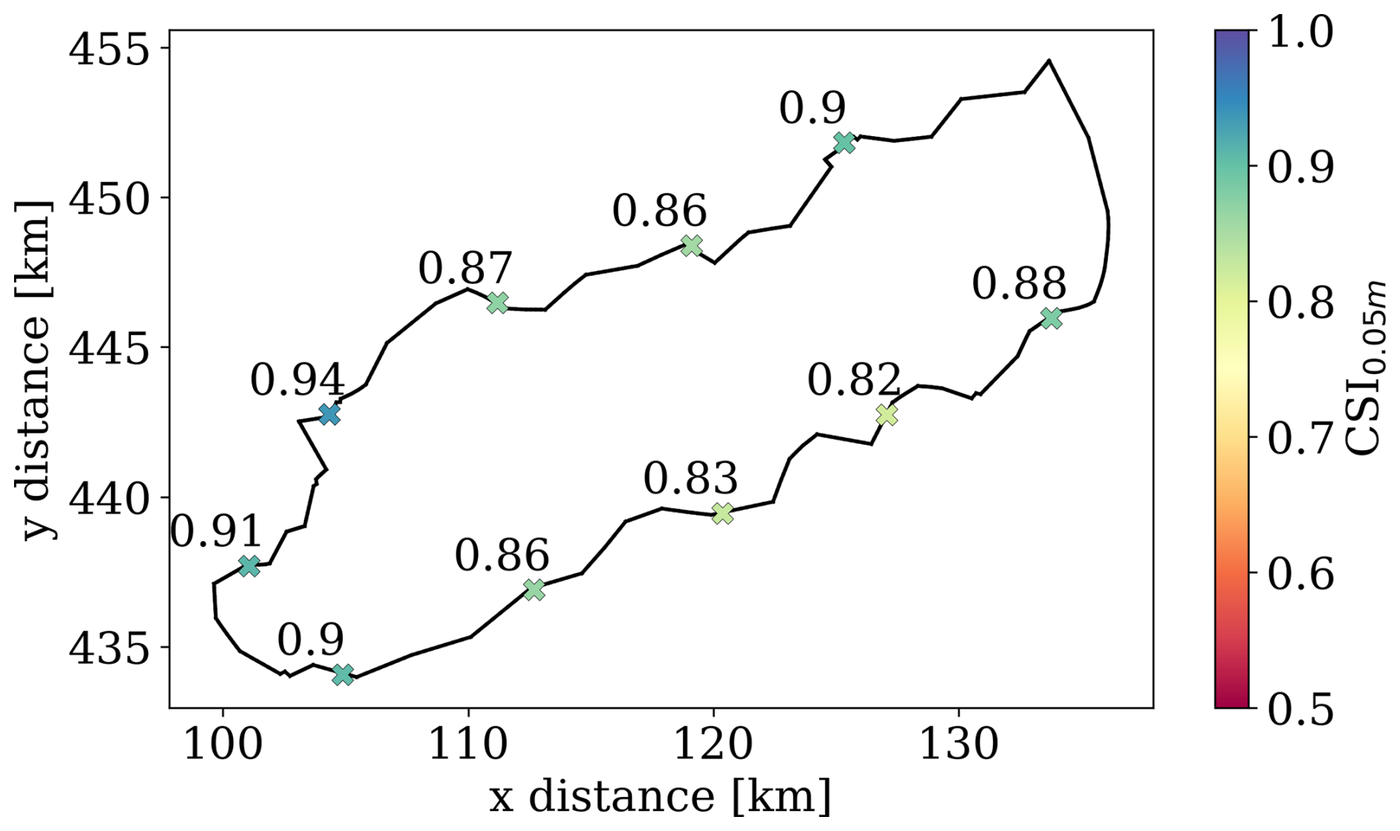

*Fig. 11 —* CSI$_{0.05}$ of the fine-tuned model at all 10 test breach locations: 0.82–0.94, showing that fine-tuning on a single breach generalises to the rest of the ring, with different inflow directions and basin responses.

*Figure source: Bentivoglio et al., NHESS 25, 335–351, 2025, [doi:10.5194/nhess-25-335-2025](https://doi.org/10.5194/nhess-25-335-2025), CC BY 4.0.*

#### In the code: load `finetuned_dk15.h5` and roll it out on the 10 dike-ring-15 test simulations
`config_finetune.yaml` fine-tunes on 1 dike-ring-15 simulation and tests on the remaining 10 (22 880 fine-mesh cells, about 30 000 nodes per sample). Here we only load the authors' fine-tuned checkpoint and test it.

In [ ]:
cfg_ft = read_config("config_finetune.yaml")
wandb.finish(); wandb.init(mode="disabled", config=cfg_ft); fix_dict_in_config(wandb); config_ft = wandb.config
_, _, test_dk15, scalers_ft = create_model_dataset(scalers=config_ft.scalers, device=device, **config_ft.dataset_parameters,
                                                   **config_ft.selected_node_features, **config_ft.selected_edge_features)
# ---------------- FAST VARIANT ----------------------------------------------------
# These meshes carry ~30 000 nodes each, about twice the synthetic ones, so each rollout
# costs roughly twice as much. 2 of the 10 breach locations is enough to show the
# transfer case; the per-location CSI figure below simply has fewer points.
N_DK15 = 2
test_dk15 = test_dk15[:N_DK15]
# ----------------------------------------------------------------------------------
print(len(test_dk15), "dijkring-15 test simulations;", test_dk15[0].num_nodes, "nodes each; node_ptr", test_dk15[0].node_ptr.tolist())
plm_ft = load_plmodule(config_ft.saved_model, config_ft, test_dk15[0])
# pred_ft, t_ft = run_rollout(plm_ft, test_dk15, batch_size=5)   # full notebook
pred_ft, t_ft = run_rollout(plm_ft, test_dk15, batch_size=2)     # FAST VARIANT
num_times_ft = get_numerical_times("dijkring_15_test", len(test_dk15), temporal_res, test_dk15[0].WD.shape[1],
                                   **temporal_test_dataset_parameters, overview_file="database/overview.csv")
sa_ft = SpatialAnalysis(pred_ft, t_ft, test_dk15, **temporal_test_dataset_parameters)
rl = sa_ft._get_rollout_loss(type_loss="RMSE"); sp, sp_std = get_speed_up(num_times_ft, sa_ft.prediction_times)
pd.Series({"test roll loss WD": rl.mean(0)[0].item(), "test roll loss V": rl.mean(0)[1:].mean().item(),
           "test CSI_005": sa_ft._get_CSI(0.05).nanmean().item(), "test CSI_03": sa_ft._get_CSI(0.3).nanmean().item(),
           "speed-up": float(sp)}, name="finetuned_dk15 on dijkring_15 test").round(4)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
sa_ft.plot_CSI_rollouts(water_thresholds=[0.05, 0.3], ax=axs[0]); sa_ft._plot_rollouts(type_loss="MAE", ax=axs[1]); axs[0].grid(False); plt.tight_layout()
rl_ft = sa_ft._get_rollout_loss(type_loss="RMSE"); best_ft = rl_ft.mean(1).argmin().item()
rp_ft = PlotRollout(plm_ft.model.to(device), test_dk15[best_ft].to(device), scalers=scalers_ft, type_loss="RMSE", **temporal_test_dataset_parameters)
fig = rp_ft.explore_rollout(time_step=-1, scale=0, logscale=True); fig.suptitle(f"dijkring 15, best test simulation (id {best_ft})", y=1.02);

### 4.3 Ablation study (§4.3, paper Table 3)

| Configuration | Val RMSE [m] | Val CSI$_{0.05}$ | Test RMSE [m] | Test CSI$_{0.05}$ |
|---|---|---|---|---|
| **mSWE-GNN (full)** | **0.044** | **0.956** | **0.052** | **0.943** |
| w/o multi-scale module | 0.051 | 0.948 | 0.061 | 0.929 |
| learnable downsampling (instead of mean pooling) | 0.048 | 0.950 | 0.056 | 0.936 |
| w/o skip connections (Eq. 7) | 0.045 | 0.955 | 0.053 | 0.941 |
| residual decoder (instead of the 1-D CNN of Eq. 8) | 0.046 | 0.954 | 0.054 | 0.940 |
| rotation-dependent inputs | 0.051 | 0.947 | 0.061 | 0.928 |

*These numbers were transcribed from the article text; check them against the original table before quoting.* The conclusion: the **multi-scale module** and the **rotation-invariant inputs** contribute most (removing either raises the test RMSE by about 17 %); the skip connections and the decoder form matter less but point the same way. This maps back onto the gaps in section 1: multi-scale addresses the range of propagation speeds and the instability of deep stacks, rotation invariance improves sample efficiency.

## 5. Discussion and conclusion (§5–6) + Appendix C

**Strengths (against the four gaps of section 1)**
1. The U-shaped multi-scale structure covers the domain with 2–5 layers per scale → it can represent fast and slow propagation, trains stably, and does little work on the finest scale → speed-ups of 700–1200× and a Pareto front that dominates SWE-GNN.
2. Ghost cells plus directed edges → a time-varying breach hydrograph can be used as an input.
3. Rolling out from a dry bed at $t=0$ → no numerical solver is needed for the initial condition.
4. Rotation-invariant inputs plus the graph structure → transfer to unseen meshes, topographies and boundary conditions, with a real case study needing only one simulation for fine-tuning.

**Limitations (stated by the authors)**: only dike-breach floods were evaluated (not river, coastal or pluvial floods); time-varying water-level boundaries were not tested; roughness is spatially uniform; the mesh must be generated top-down from a boundary polygon, so an existing fine mesh cannot be used directly; multiple simultaneous boundary conditions were not considered; the number of layers is the same on every scale; and there is no comparison against newer methods such as Fourier neural operators or neural fields.

**Future work**: time-varying breach-growth models; adding water bodies and linear elements (roads, secondary dikes); precipitation input and coupling with 1-D drainage for urban flooding; probabilistic multi-scenario frameworks and uncertainty quantification; PINN-style auto-differentiation losses; larger training sets to remove the need for fine-tuning; JIT/IPU acceleration.

### Appendix C: speed-up from parallel inference (paper Fig. 14)

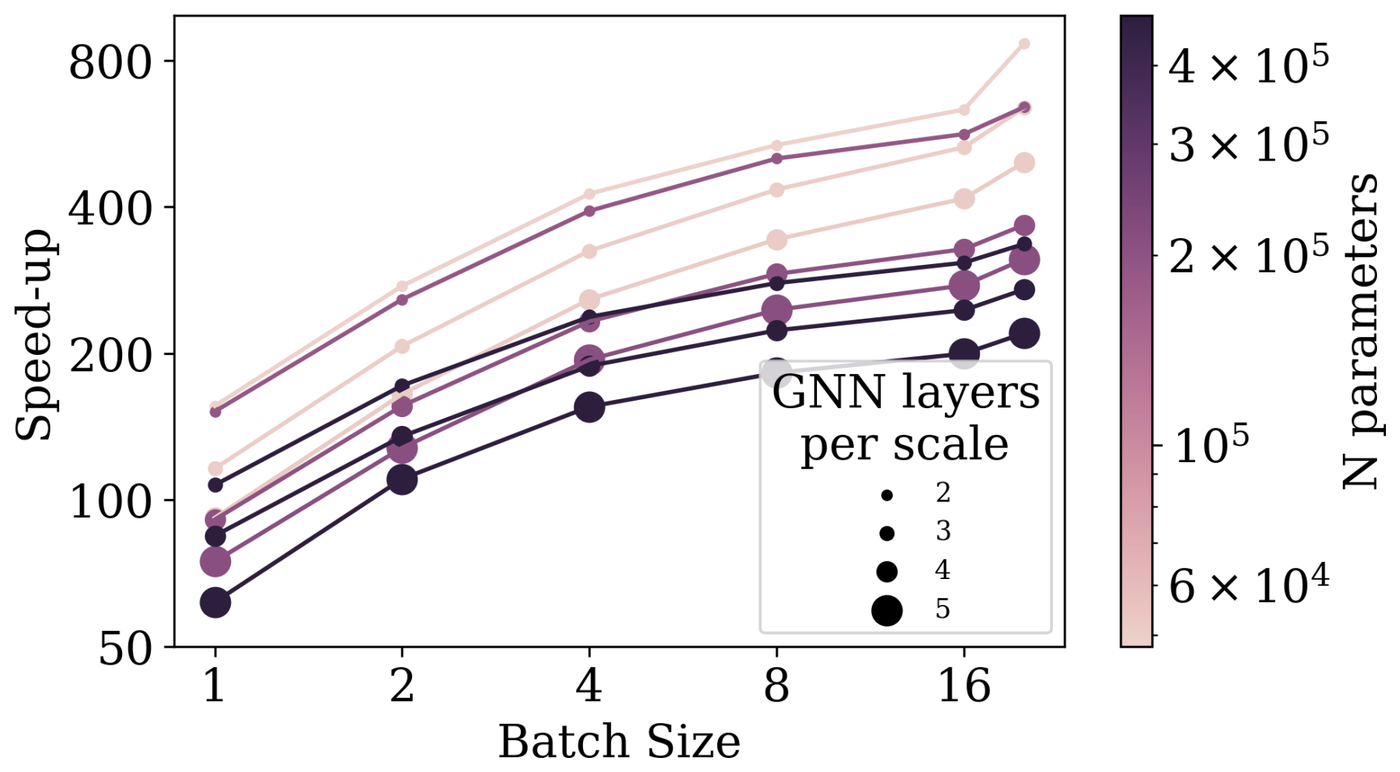

*Fig. 14 —* Speed-up of the 16 Pareto models on the synthetic test set as a function of batch size, i.e. how many simulations are inferred in parallel (both axes log). Running 20 simulations in parallel buys another ~4.5×; models with more layers (larger dots) and more parameters (darker) benefit less. Counting the runtime of the one numerical simulation needed for fine-tuning, the overall speed-up on the real case study is about 4–8×.

*Figure source: Bentivoglio et al., NHESS 25, 335–351, 2025, [doi:10.5194/nhess-25-335-2025](https://doi.org/10.5194/nhess-25-335-2025), CC BY 4.0.*

#### In the code: the repo's recorded parallel-inference timings and mass-conservation experiment (read from csv, not re-run)
- `batch_prediction_times.csv`: inference time as a function of batch size (several simulations inferred in parallel).
- `mass_conservation.csv`: the effect of the mass-conservation loss weight (`trainer_options.conservation`) on accuracy.

In [ ]:
bt = pd.read_csv("results/batch_prediction_times.csv"); mc = pd.read_csv("results/mass_conservation.csv")
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
for (K, F), g in bt.groupby(["K", "hid_feats"]):
    axs[0].plot(g["batch_size"], g["prediction_times"], "o-", label=f"K{K} F{F}")
axs[0].set_xscale("log", base=2); axs[0].set_yscale("log"); axs[0].set_xlabel("batch size (simulations in parallel)"); axs[0].set_ylabel("prediction time [s]"); axs[0].legend(fontsize=7, ncol=2); axs[0].grid(alpha=0.3)
axs[1].scatter(mc["trainer_options.conservation"], mc["test CSI_005"], label="CSI 0.05"); axs[1].scatter(mc["trainer_options.conservation"], mc["test CSI_03"], label="CSI 0.3")
axs[1].set_xlabel("mass-conservation loss weight"); axs[1].set_ylabel("test CSI"); axs[1].legend(); axs[1].grid(alpha=0.3)
plt.tight_layout()

### 5.1 Carrying this over to a static, single-pass raster model

Applying the conclusion of §2.2.1 to a static dam-break inundation model — a 19-channel raster U-Net that predicts a single maximum-inundation envelope rather than a time series — requires separating which of mSWE-GNN's two mechanisms can transfer.

**The two have different long-range structure**

| | mSWE-GNN | Static raster U-Net |
|---|---|---|
| Task | time evolution $h(t), q(t)$, 48 steps | static maximum-inundation envelope, one pass |
| Single-pass receptive field | 8.1 km (63 % of the domain) | capped by the 512 px crop, 30.7 km at 60 m/px |
| Domain scale | 13 km synthetic / 36 km dike ring 15 | canvases with a median long side of 159 km |
| Coupling beyond the local window | multi-scale (per step) + autoregression (across steps) | none: tiles are inferred independently, overlaps are only averaged |
| Source of long-range information | the architecture | hand-computed channels (flow distance, attenuated discharge, distance to the dam) |

**The multi-scale half transfers.** Adding a coarse global branch to the U-Net — encoding the whole canvas downsampled and concatenating it with the fine crop's bottleneck features — is exactly mSWE-GNN's multi-scale mechanism, and could in principle replace the hand-computed along-path channels.

**The autoregressive half does not.** A static envelope has no time axis, so there is no mechanism to spread the coupling over multiple steps; global context has to be supplied by the architecture in one shot. For a static task that may well be the right trade-off, but it should be stated explicitly, because "add a coarse branch and you have mSWE-GNN" would be wrong.

**A note on citing the numbers: do not compare against the 700× speed-up directly.** That ratio is measured against one 48-step Delft3D run. A static surrogate trained on published inundation maps replaces an entire modelling study rather than a single solver run, which is a different context. The same caution applies to CSI: it is the same quantity as binary IoU, but mSWE-GNN's 0.88 is a single dike ring, after fine-tuning, and scored against the same solver that generated the labels.

## 6. Reproduction findings and cluster-specific pitfalls
**Findings**
- Training can be skipped entirely: the 17 checkpoints shipped with the repo are compatible with the current code and data, and `test_model.py` (or this notebook) is enough to test them.
- `K4_F64` on the real test set: CSI$_{0.05}$ ≈ 0.80 and CSI$_{0.3}$ ≈ 0.66 (the repo records 0.83 / 0.69, within 0.03). But the water-depth **RMSE ≈ 0.084 m**, well above the 0.050 m recorded in the repo (the MAE of 0.051 m happens to be numerically close, but it is a different quantity). Flood-extent metrics reproduce well; pointwise depth error does not, and the cause is not yet identified.
- Possible sources of the difference, none of them verified: the pickles were rebuilt with meshkernel 3.0.0 (the coarse meshes may differ slightly from the authors'), AMP, and the `*_dataset2` dataset variants used in the authors' own notebook.

**Pitfalls when reproducing this on a cluster**
1. `lightning` must be 2.0.9.post0 (see requirements.txt); ≥2.1 raises a TypeError because `plmodule.load_from_checkpoint` is called on an instance.
2. The `WandbLogger` of Lightning ≥2 is lazy; this notebook calls `wandb.init(mode="disabled")` first and then `fix_dict_in_config`.
3. Zenodo's API and web pages returned 403 from this cluster, but `wget` on the direct file URLs works; `curl` is broken on this machine.
4. The polygon files in the data archive are lower-case `polygon_{i}.pol`; `create_mesh_dataset` was changed accordingly (`database/graph_creation.py:1612`).
5. For a full training run (200 epochs) use `sbatch plan/sbatch_gpu_real.sh` (setting `max_epochs` back to 200).